# SONG HIGHLIGHTER : Piano di Consulenza per una Label Discografica

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

df = pd.read_csv('song_ready2.csv')
df

,artist,song,explicit,year,popularity,danceability,energy,loudness,speechiness,acousticness,...,folk,hip hop,jazz,latin,metal,pop,r&b,rock,traditional,world
0,britney spears,oops!...i did it again,False,2000,0.865,0.735,0.825,0.745,0.037,0.307,...,0,0,0,0,0,1,0,0,0,0
1,blink-182,all the small things,False,1999,0.888,0.360,0.892,0.771,0.046,0.010,...,0,0,0,0,0,1,0,1,0,0
2,faith hill,breathe,False,1999,0.742,0.473,0.467,0.569,0.010,0.177,...,0,0,0,0,0,1,0,0,0,0
3,bon jovi,it's my life,False,2000,0.876,0.499,0.909,0.813,0.042,0.027,...,0,0,0,0,1,0,0,1,0,0
4,nsync,bye bye bye,False,2000,0.730,0.573,0.925,0.776,0.051,0.042,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,jonas brothers,sucker,False,2019,0.888,0.843,0.719,0.763,0.064,0.044,...,0,0,0,0,0,1,0,0,0,0
1996,taylor swift,cruel summer,False,2019,0.876,0.500,0.685,0.732,0.242,0.120,...,0,0,0,0,0,1,0,0,0,0
1997,blanco brown,the git up,False,2019,0.775,0.849,0.660,0.587,0.155,0.068,...,0,1,0,0,0,0,0,0,0,0
1998,sam smith,dancing with a stranger (with normani),False,2019,0.843,0.723,0.493,0.642,0.077,0.461,...,0,0,0,0,0,1,0,0,0,0


# DOMANDA DI BUSINESS 1 

Il primo atto è fondamentale: dobbiamo dimostrare alla casa discografica che il mercato non è statico, ma un'entità in movimento. Se ignorano questi trend, produrranno musica per un pubblico che non esiste più.

## Atto I: La Metamorfosi del Suono (Domanda di Business 1)
Obiettivo: Analizzare come le 8 caratteristiche audio si sono evolute dal 1998 al 2020 per identificare la "direzione artistica" del mercato globale.

Per questo grafico useremo Plotly. Perché? Perché è interattivo. Durante una presentazione, poter passare il mouse sopra una linea e vedere l'anno esatto e il valore preciso della danceability comunica una professionalità che un grafico statico si sogna.

In [2]:
# Definizione semantica delle variabili dell'audio
market_drive_indicators = ['danceability', 'energy', 'loudness', 'speechiness']
artistic_soul_factors = ['acousticness', 'instrumentalness', 'liveness', 'valence']

# L'insieme completo per l'analisi del DNA sonoro
sonic_fingerprint = market_drive_indicators + artistic_soul_factors
# Raggruppiamo per anno e calcoliamo la media delle 8 feature
yearly_trends = df.groupby('year')[sonic_fingerprint].mean().reset_index()

### spikeline audio feature

Studio dell'elvoluzione delle caratteristiche audio della musica sul mercato discografico dal 1998 al 2020.

In [3]:
# Setup Figura
fig = go.Figure()

color_map = {
    'danceability': '#FF8C00', 'energy': '#DC143C', 'loudness': '#555555',
    'speechiness': '#E7ACE2', 'acousticness': '#4169E1', 'instrumentalness': '#B0B0B0',
    'liveness': '#19A353', 'valence': '#FFC000'
}

# Inserimento Tracce
for feature in sonic_fingerprint:
    fig.add_trace(go.Scatter(
        x=yearly_trends['year'], 
        y=yearly_trends[feature],
        mode='lines+markers',
        name=feature.replace('_', ' ').capitalize(),
        line=dict(width=2.5, color=color_map[feature]),
        marker=dict(size=5),
        hovertemplate=f'<b>{feature.capitalize()}</b>: %{{y:.2f}}<extra></extra>'
    ))

# GESTIONE EVENTI (Posizionamento millimetrico 1998.25)
events = [
    # 1998 + (1/4 di 1 anno) = 1998.25
    dict(year=1998.25, text="Auto-Tune Era", xanchor="left"), 
    dict(year=2005, text="DAW Revolution", xanchor="left"),
    dict(year=2013, text="Streaming Peak", xanchor="right"),
    dict(year=2019, text="TikTok Revival", xanchor="right")
]

for ev in events:
    # Linea verticale
    fig.add_vline(x=ev['year'], line_width=1.5, line_dash="dot", line_color="#7f8c8d")
    
    # Etichetta Orizzontale interna al plot area
    fig.add_annotation(
        x=ev['year'],
        y=0.92,              
        text=ev['text'],
        showarrow=False,
        font=dict(size=9, color="#444444", family="Arial Bold"),
        textangle=0,         
        xref="x", yref="y",
        xanchor=ev['xanchor'], 
        xshift=8 if ev['xanchor']=="left" else -8, # Offset per distanziarla dalla linea
        bgcolor="rgba(255, 255, 255, 0.8)"
    )

# Layout Executive - Intersezione Netta 1998/0
fig.update_layout(
    template='plotly_white',
    title=dict(
        text='<b>Come è evoluta la musica e le sue caratteristiche sonore dal 1998 al 2020? Evolution Sonic Fingerprint (1998-2020)</b><br>' +
             '<span style="font-size:14px; color:#666666;">Analisi delle evoluzioni audio e dei driver tecnologici di mercato</span>',
        x=0.5, y=0.97, xanchor='center', yanchor='top'
    ),
    xaxis=dict(
        title='Anno di Analisi',
        tickmode='linear', 
        tick0=1998, 
        dtick=2,
        range=[1998, 2020],    # Taglio netto all'origine
        showgrid=True, gridcolor='#F2F2F2',
        linecolor='black', mirror=True,
        # Impedisce a Plotly di aggiungere spazio bianco ai bordi
        automargin=False
    ),
    yaxis=dict(
        title='Valore Medio (scala 0 - 1)',
        tickmode='linear', tick0=0, dtick=0.1,
        range=[0, 1],          # Taglio netto 0-1
        showgrid=True, gridcolor='#F2F2F2',
        linecolor='black', mirror=True,
        automargin=False
    ),
    hovermode='x unified',
    margin=dict(l=70, r=40, t=110, b=70), 
    legend=dict(
        orientation="h",
        yanchor="bottom", y=1.02,
        xanchor="center", x=0.5,
        font=dict(size=10),
        bordercolor='#EEEEEE', borderwidth=1
    ),
    height=750
)

fig.show()

1. La "Guerra del Volume" e la saturazione (Loudness & Energy)Guarda l'inizio del grafico (1998-2000). C'è un'impennata verticale di Loudness (Nero Fumé) ed Energy (Cremisi).Dal 2000 in poi, queste due linee viaggiano a braccetto nella fascia alta ($0.7 - 0.8$).Insight: Il mercato è saturo di volume. Se oggi produci un brano che sta sotto lo $0.7$ di Energy, rischi che "sparisca" radiofonicamente. È diventato lo standard minimo di sopravvivenza commerciale.

2. Il declino della "Felicità" (Valence)Questa è l'osservazione più interessante: la linea Giallo Oro (Valence) ha una pendenza negativa costante, specialmente dal 2012 in poi.Trend: La musica sta diventando "più triste" o introspettiva. Nonostante l'energia e il volume restino alti, il sentiment (Valence) cala.Opportunità: C'è un vuoto di mercato per canzoni "Feel Good" che abbiano alta Valence, dato che la concorrenza si sta spostando su tonalità più scure e malinconiche.

3. La resilienza della Danceability (Arancio)Noti come la Danceability (il tuo nuovo Arancio Forte) sia l'unica a restare granitica sopra lo $0.6$?Nonostante i generi cambino (dal Pop-Rock al Reggaeton alla Trap), il "ritmo" è l'asset più stabile. Se vuoi investire su un nuovo artista per SongHighlighter, la Danceability è l'assicurazione sulla vita dell'investimento.

4. Il "Rumore di Fondo" (Soul Assets)Hai ragione nel dire che Acousticness, Instrumentalness e Speechiness sembrano piatte sul fondo. Ma guarda il 2018-2020:C'è un piccolo "risveglio" dell'Acousticness (Blue) e della Liveness (Verde).Dopo anni di dominio sintetico, il pubblico sta ricominciando a cercare suoni più organici. È un segnale debole, ma per un produttore è il momento di inserire strumenti reali nelle produzioni per anticipare il trend "Back to Basics".

### GroupedBarPlot DNA-HIT dianimc-interactive

Qui abbiamo bisogno di definere alcuni tagli importanti sulla popolarità per effettuare il prossimo grafico. Cerchiamo di dare un senso alle alternative che abbiamo:

1. La "Soglia del Successo" 80% o 0.8: 
Nel settore dei dati musicali (es. API di Spotify), la popolarità è una misura relativa basata sul volume totale di streaming e sulla recenza. Gli esperti di data-science musicale (come quelli di Chartmetric o Soundcharts) osservano che un punteggio superiore a 80 colloca l'artista nel Top 0.1% globale. Brani con questo score sono solitamente inseriti nelle playlist delle Top Hits. Per questo possiamo considerare tale soglia come la soglia delle HITS.


2. Il "Long Tail of Fail or Starting" e la soglia del 20% o 0.2:
Per quanto riguarda la soglia bassa, definire "disprezzato" un brano sotto il 20% potrebbe essere un termine forte, poiché gran parte della musica caricata sulle piattaforme è soggetta alla cosiddetta Long Tail di Chris Anderson e fatica a superare il 10%. Questo però non sempre significa che la musica non crescerà in popolarità in seguito con il passare del tempo, ma è pur vero che in questa zona ci sono anche brani che restano a popolarità bassa proprio perchè non riesco a fare impatto sugli ascoltatori. Gli analisti definiscono questa zona come "Niche" o "Undiscovered". In uno studio sulla popolarità degli algoritmi, i brani sotto il 20 spesso mancano dei metadati comportamentali (skip rate, salvataggi) che permetterebbero di discriminare le due fasi con estrema precisione. Per cui oltre al concetto di "Zombie Tracks" (canzoni con quasi zero ascolti) o brani in fase di "Seedling" (semi che devono ancora germogliare) possiamo affiancare anche il concetto di actaula Fail.

In un quadro più generale che potrebbe essere di aiuto in seguito usiamo questa classificazione adottata da Data Scientist esperti nel settore musicale come quelli  Chartmetric o Soundcharts:

| Popolarità | Classificazione Tecnica | Significato per il Produttore |
| :--- | :--- | :--- |
| **0 - 20** | **Emerging / Deep Catalog** | Brani nuovi o di nicchia estrema. Mancanza di trazione organica. |
| **21 - 50** | **Mid-Tier / Developing** | Artisti con una base fan solida ma locale. Potenziale crescita. |
| **51 - 79** | **High Rotation / Regional Hits** | Brani che dominano i generi specifici (es. R&B Dark) ma non sono ancora "pop" globale. |
| **80 - 100** | **Global Blockbusters** | Le cosiddette "Hit Songs". Massima vendibilità e valore di marketing. |

In alternativa senza avere queste informazioni di dominio estremamente importanti avremmo optato per affidarci alla statistica e avremmo considerato delle percentuali che ci avrebbero fatto stare al di sotto del 25% per la zona del Fail o emerging e sopra il 75% per la zona delle top hits.


In [4]:
"""_configurazione su quartili_

# ─────────────────────────────────────────────
# CONFIGURAZIONE — soglie basate sui quartili 
# ─────────────────────────────────────────────
Q25 = df['popularity'].quantile(0.25)   # → 0.560 or less
Q75 = df['popularity'].quantile(0.75)   # → 0.730 or more

low_filter  = df[df['popularity'] < Q25]
mid_filter  = df[(df['popularity'] >= Q25) & (df['popularity'] < Q75)]
hits_filter = df[df['popularity'] >= Q75]
"""

# ─────────────────────────────────────────────
# CONFIGURAZIONE — soglie fisse
# ─────────────────────────────────────────────
LOW_MAX  = 0.2
MID_MAX  = 0.8

low_filter  = df[df['popularity'] < LOW_MAX]
mid_filter  = df[(df['popularity'] >= LOW_MAX) & (df['popularity'] < MID_MAX)]
hits_filter = df[df['popularity'] >= MID_MAX]

n_low  = len(low_filter)   # 218
n_mid  = len(mid_filter)   # 1055
n_hits = len(hits_filter)  # 727

# Calcolo Medie (arrotondate a 3 decimali)
low_mean  = low_filter[sonic_fingerprint].mean()
mid_mean  = mid_filter[sonic_fingerprint].mean()
hits_mean = hits_filter[sonic_fingerprint].mean()

labels   = [f.replace('_', ' ').capitalize() for f in sonic_fingerprint]
val_low  = [round(v, 3) for v in low_mean.values]
val_mid  = [round(v, 3) for v in mid_mean.values]
val_hits = [round(v, 3) for v in hits_mean.values]

# Posizionamento testi (Instrumentalness fuori, resto dentro)
pos_instr = labels.index('Instrumentalness')
def make_pos(n):
    p = ['inside'] * n
    p[pos_instr] = 'outside'
    return p

pos_low  = make_pos(len(labels))
pos_mid  = make_pos(len(labels))
pos_hits = make_pos(len(labels))

fig = go.Figure()

# Traccia Bassa Popolarità — Bronzo scuro
fig.add_trace(go.Bar(
    x=labels, y=val_low,
    name=f'Bassa Popolarità - Fail (< {LOW_MAX}, n={n_low})',
    marker_color='#795548',
    marker_line=dict(color='#4E342E', width=1.0),
    text=val_low,
    textposition=pos_low,
    insidetextanchor='end',
    textfont=dict(size=9, color='white'),
    hovertemplate='Bassa Pop: %{y:.3f}<extra></extra>'
))

# Traccia Media di Mercato — Grigio neutro
fig.add_trace(go.Bar(
    x=labels, y=val_mid,
    name=f'Media delle Traccie di Mercato ({LOW_MAX}–{MID_MAX}, n={n_mid})',
    marker_color='#B0BEC5',
    text=val_mid,
    textposition=pos_mid,
    insidetextanchor='end',
    textfont=dict(size=9),
    hovertemplate='Mercato: %{y:.3f}<extra></extra>'
))

# Traccia Hit — Giallo oro
fig.add_trace(go.Bar(
    x=labels, y=val_hits,
    name=f'Alta popolarità - Top Hits (>= {MID_MAX}, n={n_hits})',
    marker_color='#FFD700',
    marker_line=dict(color='#B8860B', width=1.2),
    text=val_hits,
    textposition=pos_hits,
    insidetextanchor='end',
    textfont=dict(size=9, color='black'),
    hovertemplate='Alta Popolarità - Top Hits: %{y:.3f}<extra></extra>'
))

# Bottoni VALORI ON/OFF
fig.update_layout(
    updatemenus=[
        dict(
            type="buttons",
            direction="down",
            showactive=True,
            x=0.99, y=0.98,
            xanchor='right', yanchor='top',
            pad={"r": 0, "t": 0},
            font=dict(size=10, color="#333"),
            buttons=[
                dict(
                    label="MOSTRA VALORI",
                    method="update",
                    args=[{"text": [val_low, val_mid, val_hits]}]
                ),
                dict(
                    label="NASCONDI VALORI",
                    method="update",
                    args=[{"text": [None, None, None]}]
                ),
            ]
        )
    ]
)

# Annotazioni Insight

# Acousticness — avvicinata (ay meno negativo)
fig.add_annotation(
    x='Acousticness', y=hits_mean['acousticness'] + 0.005,
    xref="x", yref="y",
    text="<b>NOTA PER PRODUZIONE:</b><br>Digitalizzazione massiccia.<br>Texture digitali dominanti.",
    showarrow=True, arrowhead=2, arrowcolor="#C62828",
    ax=55, ay=-70,
    bordercolor="#C62828", borderwidth=2,
    bgcolor="rgba(255,255,255,0.8)",
    font=dict(size=10, family="Arial Bold")
)

# Energy — riquadro spostato in alto a sinistra, fuori dalla barra
fig.add_annotation(
    x='Energy', y=hits_mean['energy'] + 0.05,
    xref="x", yref="y",
    text="<b>NOTA PER PRODUZIONE:</b><br>L'energia ha una lieve diminuzione.<br>",
    showarrow=True, arrowhead=2, arrowcolor="#C62828",
    ax=-80, ay=-40,
    bordercolor="#C62828", borderwidth=2,
    bgcolor="rgba(255,255,255,0.8)",
    font=dict(size=10, family="Arial Bold")
)

# Valence — riquadro spostato in alto a destra, fuori dalla barra
fig.add_annotation(
    x='Valence', y=hits_mean['valence'] + 0.06,
    xref="x", yref="y",
    text="<b>NOTA PER PRODUZIONE:</b><br>La positività si abbassa.<br>Sfumature più cupe.",
    showarrow=True, arrowhead=2, arrowcolor="#C62828",
    ax=-80, ay=-40,
    bordercolor="#C62828", borderwidth=2,
    bgcolor="rgba(255,255,255,0.8)",
    font=dict(size=10, family="Arial Bold")
)

# 8. Layout Finale
fig.update_layout(
    template='plotly_white',
    title=dict(
        text=(
            f"<b>Come suona una hit o una fail rispetto al mercato medio? DNA delle Hit e delle Fail</b><br>"
            f'<span style="font-size:13px; color:#666666;">'
            f"Punto di riferimento dell'eccellenza: Analisi comparativa per fascia di popolarità  "
            f'Bassa - Media - Alta'
            f'</span>'
        ),
        x=0.5, y=0.96, xanchor='center'
    ),
    xaxis=dict(
        title=dict(text='Caratteristiche audio del DNA sonoro', font=dict(size=12, family='Arial Bold')),
        tickfont=dict(size=10)
    ),
    yaxis=dict(
        title=dict(text='Valore medio (scala del valore 0 - 1)', font=dict(size=12, family='Arial Bold')),
        range=[0, 1.0],
        gridcolor='#F2F2F2',
        dtick=0.1
    ),
    barmode='group',
    legend=dict(
        orientation="h",
        yanchor="bottom", y=1.02,
        xanchor="center", x=0.5,
        font=dict(size=10)
    ),
    margin=dict(l=70, r=40, t=150, b=80),
    height=650
)

fig.show()

Se le medie delle Hit sono quasi sovrapposte alle medie del Mercato stadard e a quelle del traccie Fail or Emerging questo sta a significa che il mercato è estremamente efficiente. In pratica, non esiste più una "formula segreta" tecnica che solo le hit possiedono; quasi tutta la musica prodotta e distribuita oggi rispetta già gli standard qualitativi necessari per essere una hit o comunque per funzionare in radio e fare ascolti.

Tuttavia, proprio questa mancanza di scostamenti pazzeschi è un insight di business fondamentale, infatti, non è nei singoli parametri tecnici che si vince la partita, perché ormai tutti producono musica con lo stesso 'DNA base'. La differenza tra un flop e una hit da 100 milioni di stream non è più una questione di quanto è 'dance', ma di come queste caratteristiche si combinano emotivamente. Infine possiamo dire che potrebbe essere qualche altra variabile non conteplata tra quelle esaminate che sia correlata al successo o all'ascolto di una hit.

- SATURAZIONE DEL MERCATO DAL PUNTO DI VISTA TECNICO C'E' GIA' LA RICETTA DEL SUCCESSO
- LA POPOLAIRTA' CHE FA UNA HIT E' DATA DA QUALCOSALTRO

In [5]:
#sum(df['popularity'] > 0.78)

# DOMANDA DI BUSINESS 2

2. Analisi del Potenziale di Successo (La Struttura) --> Analisi della Dominanza: Giganti vs Indipendenti

Dopo aver capito le tendenze della musica attuale, bisogna capire chi possiede il mercato. È un mercato in cui dominano pochi artisti che producono hit a raffica, o c'è spazio per nuovi nomi? Serve a valutare il rischio di ingresso per un nuovo talento e dove questo possa trovare spazio in quali genere e perchè?

**(Competitor) → Chi comanda???**

L'Antagonista e "La Dominanza": "Ma chi comanda davvero? Ecco i giganti che dobbiamo sfidare. È un mercato per pochi o c'è spazio per noi?"


In [6]:
#import plotly.graph_objects as go

# 1. Preparazione dati
artist_data = df.groupby('artist').agg({
    'popularity': 'mean',
    'song': 'count'
}).reset_index()
artist_data.columns = ['Artista', 'Popolarita_Media', 'Volume_Brani']

# 2. Definizione Scala Divergente (Blu - Bianco - Arancio)
# 2. Scala Semaforo — Rosso → Giallo Paglierino → Verde
custom_scale = [
    [0.0,  '#FF1744'],   # Rosso Brillante
    [0.2, "#FF5724"],   # Rosso che schiarisce subito
    [0.3, "#FEA026"],   # Arancio caldo — zona di transizione
    [0.4, "#FCD443"],   # Giallo paglierino — inizia
    [0.55, "#CFED61"],   # Giallo paglierino — finisce (banda più larga)
    [0.65, "#7BF517"],   # Verde chiaro — entra
    [0.75, '#00C853'],   # Verdone intenso
    [1.0,  "#02933F"],   # Verde brillante — rimane stabile
]

custom_scale_inclusive = [
    # --- ZONA BASSA/ALLERTA (Arancio) ---
    [0.0,  "#DE6A17"],   # Arancio Scuro/Intenso (Valore Minimo)
    [0.2,  "#EF9F3E"],   # Arancio Chiaro/Pasto (Inizio Transizione)

    # --- ZONA NEUTRA/MEDIA (Grigio Chiaro) ---
    [0.45,  "#ECE9E9"],   # Grigio Chiarissimo (Quasi Bianco, punto di svolta 1)
    [0.55,  "#93BBCF"],   # Grigio Chiarissimo (Banda centrale più larga per stabilità)
    [0.65, "#61A0E0"],   # Grigio Chiaro (Inizio Transizione verso l'alto)

    # --- ZONA ALTA/SUCCESSO (Blu) ---
    [0.8,  "#117FF4"],   # Blu Chiaro (Inizio zona positiva)
    [1.0,  "#0454DF"]    # Blu Intenso/Brillante (Valore Massimo - La "Hit")
]

# 3. Creazione Treemap con LEGENDA REINTEGRATA
fig = go.Figure(go.Treemap(
    labels=artist_data['Artista'],
    parents=[""] * len(artist_data), 
    values=artist_data['Volume_Brani'],
    marker=dict(
        colors=artist_data['Popolarita_Media'],
        colorscale=custom_scale_inclusive,
        cmin=0,
        cmax=1,
        showscale=True, # Ritorna la legenda!
        colorbar=dict(
            title="Popolarità",
            thickness=15,
            x=1.02,
            tickvals=[0.05, 0.45, 0.9],
            ticktext=["BASSA", "NEUTRALE", "ALTA"]
        ),
        line=dict(width=0.5, color='#EEEEEE'),
        pad=dict(b=0, l=0, r=0, t=0) 
    ),
    textinfo="label+value",
    hovertemplate="<b>%{label}</b><br>Brani: %{value}<br>Popolarità: %{color:.2f}<extra></extra>"
))

"""
    title=dict(
    text="<b>Dove si posiziona il prossimo talento? Mood Gap Analysis - Genere R&B</b><br>"
            "<sup>Identificazione del varco emotivo per trovare la zona di business libera e fertile</sup>",
    x=0.5, xanchor="center", font=dict(size=22, family="Arial Black")
)
"""

# 4. Layout Executive
fig.update_layout(
    template='plotly_white',
    title=dict(
        text='<b>Chi Comanda il Mercato? Chi sono i competitor? Struttura della dominanza del mercato musicale</b><br>'
                "<sup>Indentificazione degli artisti che dominano il mercato e visione della loro popolarità</sup>",
        x=0.5, y=0.96,
        font=dict(size=22, color='black', family="Courier New")
    ),
    margin=dict(t=80, l=10, r=80, b=10), # Aumentato margine destro per la legenda
    paper_bgcolor='white'
)

fig.show()

In [7]:
from jupyter_dash import JupyterDash
from dash import dcc, html, Input, Output, ctx
import plotly.graph_objects as go
import dash

app = JupyterDash(__name__)

custom_scale_inclusive = [
    [0.0,  "#DE6A17"],
    [0.2,  "#EF9F3E"],
    [0.45, "#ECE9E9"],
    [0.55, "#93BBCF"],
    [0.65, "#61A0E0"],
    [0.8,  "#117FF4"],
    [1.0,  "#0454DF"]
]

COLORBAR = dict(
    title="Popolarità", thickness=15, x=1.02,
    tickvals=[0.05, 0.45, 0.9],
    ticktext=["BASSA", "NEUTRALE", "ALTA"]
)

artist_data = df.groupby('artist').agg(
    Popolarita_Media=('popularity', 'mean'),
    Volume_Brani=('song', 'count')
).reset_index()
artist_data.columns = ['Artista', 'Popolarita_Media', 'Volume_Brani']

# ── treemap overview artisti ──────────────────────────────────────────────────
def build_artist_treemap():
    fig = go.Figure(go.Treemap(
        labels=artist_data['Artista'],
        parents=[""] * len(artist_data),
        values=artist_data['Volume_Brani'],
        marker=dict(
            colors=artist_data['Popolarita_Media'],
            colorscale=custom_scale_inclusive,
            cmin=0, cmax=1,
            showscale=True,
            colorbar=COLORBAR,
            line=dict(width=0.5, color='#EEEEEE'),
            pad=dict(b=0, l=0, r=0, t=0)
        ),
        # ← solo nome artista nella casella
        texttemplate="<b>%{label}</b>",
        textfont=dict(size=13, family="Courier New"),
        # ← dettaglio al passaggio del mouse
        hovertemplate=(
            "<b>%{label}</b><br>"
            "Brani: %{value}<br>"
            "Popolarità media: %{color:.2f}"
            "<extra></extra>"
        )
    ))
    fig.update_layout(
        template='plotly_white',
        title=dict(
            text='<b>Chi Comanda il Mercato? Chi sono i competitor? Struttura della dominanza del mercato musicale</b><br>'
                "<sup>Indentificazione degli artisti che dominano il mercato e visione della loro popolarità</sup>"
                 '<sup>: --> Doppio click su un artista per vedere i suoi brani</sup>',
            x=0.5, font=dict(size=20, family="Courier New")
        ),
        margin=dict(t=70, l=10, r=80, b=10),
        paper_bgcolor='white'
    )
    return fig

# ── treemap brani (celle uguali) ──────────────────────────────────────────────
def build_song_treemap(artista):
    brani = (
        df[df['artist'] == artista][['song', 'popularity']]
        .drop_duplicates()
        .sort_values('popularity', ascending=False)
    )
    fig = go.Figure(go.Treemap(
        labels=brani['song'],
        parents=[""] * len(brani),
        values=[1] * len(brani),
        customdata=brani['popularity'].round(2),   # ← popolarità in customdata
        marker=dict(
            colors=brani['popularity'],
            colorscale=custom_scale_inclusive,
            cmin=0, cmax=1,
            showscale=True,
            colorbar=COLORBAR,
            line=dict(width=0.5, color='#EEEEEE'),
            pad=dict(b=0, l=0, r=0, t=0)
        ),
        texttemplate="<b>%{label}</b><br>%{customdata}",   # ← legge customdata
        textfont=dict(size=11, family="Courier New"),
        hovertemplate=(
            "<b>%{label}</b><br>"
            "Popolarità: %{customdata}"
            "<extra></extra>"
        )
    ))
    fig.update_layout(
        template='plotly_white',
        title=dict(
            text=f'<b>{artista}</b> — Dettaglio brani<br>'
                 '<sup>Colore = popolarità del singolo brano</sup>',
            x=0.5, font=dict(size=20, family="Courier New")
        ),
        margin=dict(t=70, l=10, r=80, b=10),
        paper_bgcolor='white'
    )
    return fig

# ── layout Dash ───────────────────────────────────────────────────────────────
app.layout = html.Div([

    html.Div(
        html.Button(
            "← Torna agli artisti",
            id='btn-back',
            n_clicks=0,
            style={
                'fontFamily': 'Courier New',
                'fontSize': '13px',
                'padding': '6px 16px',
                'border': '1px solid #ccc',
                'borderRadius': '4px',
                'cursor': 'pointer',
                'backgroundColor': '#f5f5f5'
            }
        ),
        id='div-back',
        style={'display': 'none', 'padding': '8px 12px'}
    ),

    dcc.Graph(
        id='treemap-main',
        figure=build_artist_treemap(),
        style={'height': '85vh'},
        config={'displayModeBar': False}
    ),

    # store: conta i click sullo stesso artista
    dcc.Store(id='store-artista',     data=None),
    dcc.Store(id='store-click-count', data=0)

], style={'backgroundColor': 'white'})


# ── callback ──────────────────────────────────────────────────────────────────
@app.callback(
    Output('treemap-main',    'figure'),
    Output('div-back',        'style'),
    Output('store-artista',   'data'),
    Output('store-click-count','data'),
    Input('treemap-main',     'clickData'),
    Input('btn-back',         'n_clicks'),
    dash.dependencies.State('store-artista',    'data'),
    dash.dependencies.State('store-click-count','data'),
    prevent_initial_call=True
)
def aggiorna(click_data, n_back, artista_corrente, click_count):

    # ── tasto "torna" ──
    if ctx.triggered_id == 'btn-back':
        return build_artist_treemap(), {'display': 'none'}, None, 0

    if click_data is None:
        raise dash.exceptions.PreventUpdate

    label = click_data['points'][0]['label']

    # ── l'artista cliccato non è nel dataset → ignore ──
    if label not in artist_data['Artista'].values:
        raise dash.exceptions.PreventUpdate

    # ── stesso artista cliccato di nuovo → conta i click ──
    if label == artista_corrente:
        nuovo_count = click_count + 1
    else:
        nuovo_count = 1

    # ── doppio click → mostra brani ──
    if nuovo_count >= 2:
        return (
            build_song_treemap(label),
            {'display': 'block', 'padding': '8px 12px'},
            label,
            0   # reset contatore
        )

    # ── primo click → niente (aspetta il secondo) ──
    return (
        dash.no_update,
        dash.no_update,
        label,
        nuovo_count
    )


app.run(mode='inline', height=700) # per vederlo nel browser http://127.0.0.1:8050/

/opt/anaconda3/envs/DM2/lib/python3.11/site-packages/dash/dash.py:644: UserWarning: JupyterDash is deprecated, use Dash instead.
See https://dash.plotly.com/dash-in-jupyter for more details.
  warnings.warn(


1. **La "Tirannia" dei Giganti (I Blocchi Grandi e Verdi)**
Rettangoli molto grandi e verde intenso, ci dicono che pochi artisti non solo producono tanto, ma colpiscono quasi sempre il bersaglio della popolarità. Sono le divinità della musica. Il loro mercato è maturo e presidiato. Entrare in competizione diretta con loro sullo stesso genere è un suicidio finanziario, specialmente se abbiamo tra le mani un nuovo artista sconosciuto che non gode della fama che hanno questi. Sono i "Market Leaders" che definiscono l'armatura pesante che bisogna avere per entrare in competizione con loro. Cattiva idea sfidarli senza un artista solido.

2. **Gli Efficienti "Killer" (Piccoli Rettangoli Verdi)**
Questi sono i più interessanti per una casa discografica indipendente. Hanno pochi brani ma sono tutti "Gold". Questi rappresentano le nuove tendenze o fenomeni virali, artisti capaci dal nulla di fare ascolti senza avere un background di fama internazionale. Hanno un rapporto sforzo/rendimento altissimo. Quindi morale e consiglio da vendere alla casa discografica: "Non serve inondare il mercato di spazzatura; serve un solo proiettile d'oro per sedersi al tavolo dei grandi". Questo permette di capire che avere un artista emeregente che riusciamo a curare nella sua forma di arte può diventare popolare anche se è al suo primo brano.

3. **La "Fabbrica del Rumore" o eterni insuccessi (Grandi Blocchi Rossi**
Rettangoli enormi ma di colore rosso scuro, ci dicono chi produce volumi di brani senza qualità (o brani di catalogo ormai freddi che non attraggono il pubblico). Questi soggetti occupano spazio nelle playlist "generiche", ma non hanno vero potere di trazione. Dimostrano che il volume da solo non garantisce la dominanza. È un monito: "Sprecate risorse in produzione massiva senza identità e finirete nel blu profondo". Quindi ci da una forte idea e punto dal quale prendere le distanze e allontanarsi il più possibile se non vogliamo fare la stessa fine e rimetterci economicamente nella produzione di un artista perdente.

4. **Il "Limbo" del Mercato (La Massa Giallo/Arancio)**
I quadratini gialli sparsi un pò ovunque sono il rumore di fondo e rappresentano gli artisti che non sono né flop né hit, ma semplicemente sono aritisti che fanno del arte un lavoro stabile con la musica che producono. Dal punto di vista del mercato discografico è la "Dead Zone", essere qui è quasi peggio che essere blu per alcuni punti di vista infatti se sei bianco per il business siginifca che non vali abbastanza per il mercato stai ammalapena a galla, di contro un artista blu, forse sta sperimentando qualche progetto con la sua casa discografica e all'inizio ancora non ha il giusto impatto oppure ci vuole del tempo per trovare la giusta componente che vitalizza la sperimentazione.

**Storytelling:**
La mappa rivela che la popolarità non è democratica. Abbiamo una chiara gerarchia di impatto: da un lato i dominatori arancioni che dettano le regole con volumi massicci, dall'altro piccoli 'cecchini' che con pochi brani riescono a scalare le classifiche. La vasta distesa gialla rossa e arancio ci avverte: il rischio più grande per un nuovo artista non è fallire (diventare rosso), ma diventare irrilevante (restare nel giallo), perdendosi in un mercato dove il volume non compensa mai la mancanza di posizionamento.

Un altro aspetto che possiamo notare e che gli artisti con questa visualizzazioni ci vengono offerti raggruppati per categorie in base alla loro produzione musicale, definendo tre fascie vistose principali:

1. I professionisti navigati che producono con costanza a sinistra
2. I professionisti che hanno una discreta produzione variabile al centro
3. Infine gli artisti che stanno provando ad emergere o sono comparsi da poco con i lori primi brani publicati a destra

## Comprende le produzioni dei generi per capire il loro valore redditizio
Adesso dommiamo continuare ad esplorare il mercato per cercare di capire dove questi competitor sono distribuiti, dato che per ora abbiamo capito solo chi evitare ovvero i Giganti i BIG della musica contro i quali avremmo pochissime probabilità di riuscita, ma ora dobbiamo capire contro chi possiamo avere buone chance e per farlo dobbiamo prima analizzare i generi e le produzioni che essi anni per capire prima quali genere siano più redditizi e poi capire chi ci lavora con tali generi.

In [8]:
song_genre = [
    'acoustic', 'blues', 'classical', 'country', 'dance', 'easy listening', 
    'electronic', 'folk', 'hip hop', 'jazz', 'latin', 'metal', 'pop', 
    'r&b', 'rock', 'traditional', 'world'
]

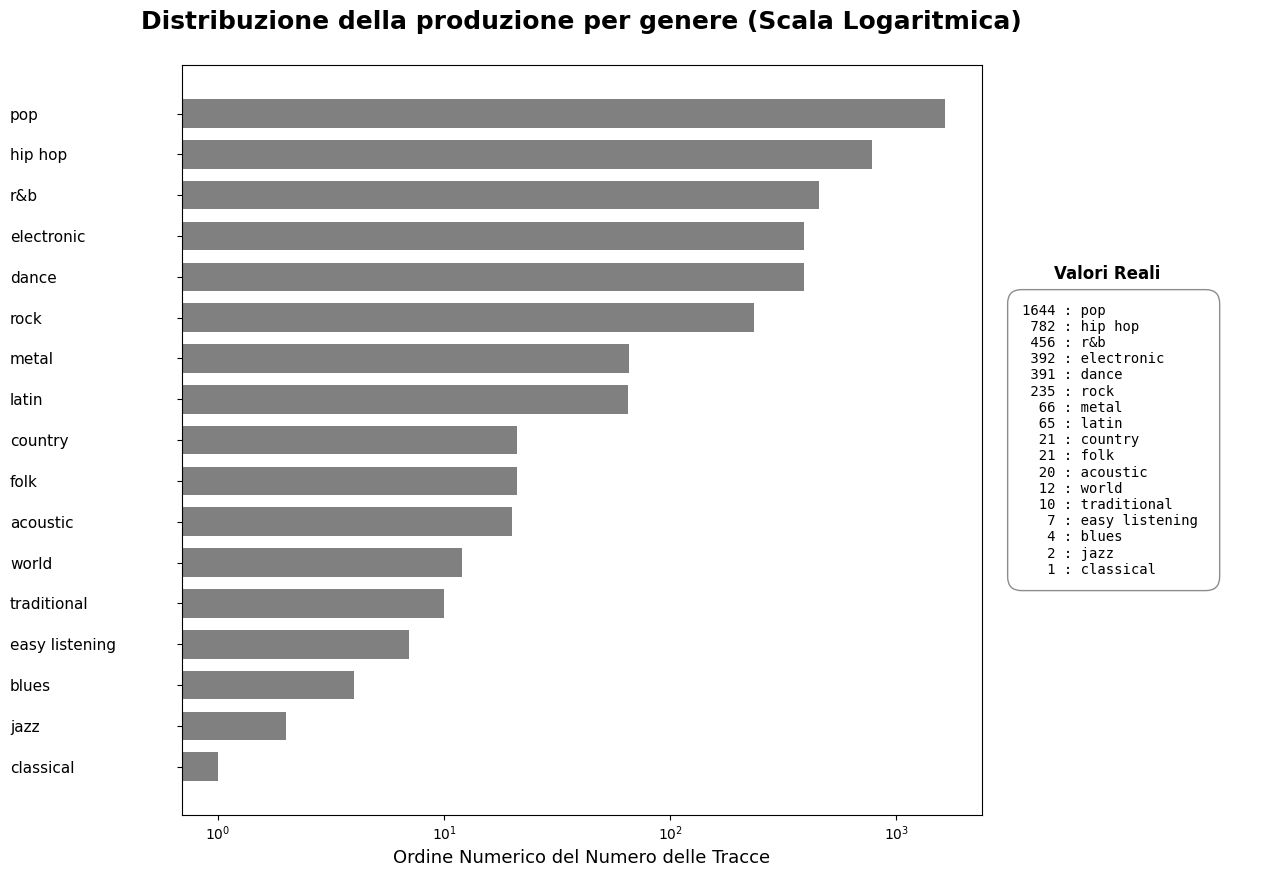

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- PREPARAZIONE DATI ---
genre_dict = {g: int(df[g].sum()) for g in song_genre}
sorted_items = sorted(genre_dict.items(), key=lambda x: x[1], reverse=True)
gen = [x[0] for x in sorted_items]
val = [x[1] for x in sorted_items]

# 1. Definiamo la figura con una larghezza molto ampia
fig, ax = plt.subplots(figsize=(20, 10)) 

# 2. Disegniamo le barre
bars = ax.barh(gen, val, color='gray', height=0.7)

# --- ASSE X E Y ---
ax.set_xscale('log')
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))
ax.xaxis.set_minor_locator(ticker.NullLocator())
ax.invert_yaxis()

# Allineamento nomi a sinistra con padding
ax.tick_params(axis='y', which='major', pad=120)
for tick in ax.get_yticklabels():
    tick.set_horizontalalignment('left')
    tick.set_fontsize(11)

# --- TABELLA E TITOLO (Posizionamento assoluto) ---
max_val_len = max(len(str(v)) for v in val)
val_lines = [f"{str(v).rjust(max_val_len)} : {g.ljust(15)}" for g, v in sorted_items]
val_text = "\n".join(val_lines)

# Usiamo coordinate relative all'asse (1.05 = appena fuori dal grafico)
x_tabella = 1.05

ax.text(1.09, 0.71, "Valori Reali", transform=ax.transAxes, 
        fontsize=12, fontweight='bold', va='bottom', ha='left')

ax.text(x_tabella, 0.5, val_text, transform=ax.transAxes, 
        fontsize=10, va='center', ha='left', fontfamily='monospace',
        bbox=dict(boxstyle="round,pad=1", facecolor="white", edgecolor="gray", alpha=0.9))

# --- IL TRUCCO PER LO SPAZIO BIANCO FINALE ---
# Aggiungiamo un elemento invisibile molto più a destra della tabella (es. a 1.4)
# Questo costringe Matplotlib a mantenere tutta l'area fino a quel punto come spazio bianco.
ax.text(1.35, .2, " ", transform=ax.transAxes) 

# --- TITOLI ---
ax.set_title("Distribuzione della produzione per genere (Scala Logaritmica)\n", 
             fontsize=18, fontweight='bold')
ax.set_xlabel("Ordine Numerico del Numero delle Tracce", fontsize=13)

# --- REGOLAZIONE FINALE RIGIDA ---
# Impostiamo il margine destro del GRAFICO al 60% della figura.
# La tabella sta tra il 61% e l'80%. 
# Dal 80% al 100% rimarrà spazio BIANCO vuoto.
plt.subplots_adjust(left=0.20, right=0.60, top=0.85, bottom=0.1)

plt.show()

In [10]:
# Prendiamo il precedente ranking ottenuto per produzione e cerchiamo di focalizzare l'attenzione su
# POP, HIP POP, R&B, ELECTRONIC, DANCE, ROCK, METAL, LATIN
import plotly.graph_objects as go

# 1. Lista generi (manteniamo l'ordine alfabetico per la legenda)
genres_to_plot = sorted([
    'acoustic', 'blues', 'classical', 'country', 'dance', 'easy listening',
    'electronic', 'folk', 'hip hop', 'jazz', 'latin', 'metal', 'pop', 
    'r&b', 'rock', 'traditional', 'world'
])

# 2. DIZIONARIO COLORI MANUALE
# Qui puoi cambiare ogni singolo colore. Ho inserito dei valori di esempio, 
# ma puoi modificarli come preferisci.
color_map = {
    'acoustic': "#f90945", 'blues':"#ffd8b1", 'classical': "#0B0B0B",
    'country': "#0514b7", 'dance': "#f88534", 'easy listening':"#911eb4",
    'electronic': "#3fd6f8", 'folk': "#008080", 'hip hop': "#800000",
    'jazz': "#a06726"  , 'latin': "#fbdc12", 'metal': "#fc5af4",
    'pop': "#567afc", 'r&b': "#919192", 'rock': "#3bc44d",
    'traditional': "#D29E9E", 'world': "#e6beff"
}

# 3. Raggruppamento dati (come prima)
stream_data = df.groupby('year')[genres_to_plot].sum().reset_index()

fig_stream = go.Figure()

# 4. Creazione tracce con colori dal DIZIONARIO
for genre in genres_to_plot:
    fig_stream.add_trace(go.Scatter(
        x=stream_data['year'],
        y=stream_data[genre],
        name=genre.upper(),
        mode='lines',
        # Recuperiamo il colore dal dizionario usando la chiave 'genre'
        line=dict(width=0.5, color=color_map.get(genre, 'gray')), 
        stackgroup='one',
        fill='tonexty',
        hoverinfo='x+y+name'
    ))

# 5. Layout (come prima)
fig_stream.update_layout(
    title=dict(
        text='<b>Come evolve la produzione dei generi nel tempo?</b><br><sup>Analisi Dinamica della Produzione dei Generi Musicali (1998-2020)</sup>',
        x=0.5, font=dict(size=22, family="Courier New")
    ),
    # title="<b>Analisi Dinamica della Produzione dei Generi Musicali (1998-2020)</b>",
    xaxis=dict(title="Anno", showgrid=False, dtick=1),
    yaxis=dict(title="Numero di Brani", showgrid=True, gridcolor='lightgray'),
    template='plotly_white',
    hovermode='closest',
    height=700,
    legend=dict(orientation="h", y=-0.2)
)

fig_stream.show()

Tramite il grafico possiamo vedere che risultano ottimi tutti i generi che vanno dal Pop in alto sino al latin, ordine è stato scelto di proposito per facilitare la letura dall'altro verso il basso e da sisnistra a destra. Per cui i generi che sembrano più produttivi anche se con enormi differrenze sono:

1. POP
2. HIP POP
3. R&B
4 ELECTRONIC
5. DANCE
6. ROCK
7. METAL
8. LATIN

Gli ultimi due hanno produzioni molto ridotte rispetto agli altri, ma potrebbe essere dovuto alla particolarità dei generi che riguardano solo ristretti gruppi di ascoltatori. Ad ogni modo ora abbiamo i generi più produttivi e vogliamo capire dove si collocano gli artisti che abbiamo precedentemente visto in overview cercandoli di segmentare rispetto alle nozioni acquisite sull'analisi della popolarità e sui grafici precedentemente proposti. Per prima cosa dovremo risolvere il problema di come assegnare ad un artista il suo genere princiaple di cui è portavoce una volta fatto potremo procedere.


In [11]:
def identify_artist_primary_genre_deterministic(df, genre_columns):
    """
    Funzione per il calcolo del genere main di un artista.
    """
    
    def get_artist_logic(artist_df):
        # 1. FREQUENZA
        counts = artist_df[genre_columns].sum()
        max_freq = counts.max()
        candidates = counts[counts == max_freq].index.tolist()
        if len(candidates) == 1: return candidates[0]

        # 2. SUCCESSO MEDIO TRAMINTE COLLABORAZIONE
        success_scores = {g: artist_df[artist_df[g] == 1]['popularity'].mean() for g in candidates}
        max_success = max(success_scores.values())
        candidates = [g for g, score in success_scores.items() if score == max_success]
        if len(candidates) == 1: return candidates[0]

        # 3. RECENCY MEDIA
        recency_scores = {g: artist_df[artist_df[g] == 1]['year'].mean() for g in candidates}
        max_year = max(recency_scores.values())
        candidates = [g for g, year in recency_scores.items() if year == max_year]
        if len(candidates) == 1: return candidates[0]

        # 4. ORDINE ALFABETICO (Deterministico)
        candidates.sort()
        return candidates[0]

    print("Calcolo in corso... (Metodo Deterministico senza Warning)")
    # Aggiungiamo include_groups=False per silenziar il FutureWarning
    artist_genres = df.groupby('artist').apply(get_artist_logic, include_groups=False).reset_index()
    artist_genres.columns = ['artist', 'primary_genre']
    return artist_genres

In [12]:
# Eseguiamo il test
artist_genre_map = identify_artist_primary_genre_deterministic(df, song_genre)

# Verifica specifica per l'artista che ti dava problemi
test_artist = "3 Doors Down"
if test_artist in artist_genre_map['artist'].values:
    print(f"\nRisultato per {test_artist}:", 
          artist_genre_map[artist_genre_map['artist'] == test_artist]['primary_genre'].values[0])

Calcolo in corso... (Metodo Deterministico senza Warning)


In [13]:
artist_genre_map['primary_genre'].value_counts()

primary_genre
hip hop           250
pop               242
dance             200
metal              34
rock               30
latin              24
acoustic           19
country            13
r&b                11
easy listening      4
blues               3
electronic          2
world               1
classical           1
folk                1
Name: count, dtype: int64

In [14]:
# Calcoliamo il volume e la popolarità media per artista dal dataset originale
artist_stats = df.groupby('artist').agg(
    song_count=('song', 'count'),
    avg_pop=('popularity', 'mean')
).reset_index()

# Uniamo con la tua mappa dei generi principali (artist_genre_map)
# Assumo che artist_genre_map abbia colonne ['artist', 'main_genre']
artist_final = artist_stats.merge(artist_genre_map[['artist', 'primary_genre']], on='artist')


In [15]:
# artist_stats

In [16]:
# SOGLIE POPOLARITÀ
POP_HIGH = 0.7
POP_LOW = 0.4

# SOGLIE VOLUME (Numero Brani)
VOL_LOW_MAX = 3   # Da 1 a 3
VOL_MID_MIN = 4   # Da 4 a 6
VOL_MID_MAX = 6
VOL_HIGH_MIN = 7  # Da 7 in su

###  Segmentazione Strategica degli Artisti (Cluster Analysis)

Questa tabella definisce i profili competitivi basati sull'incrocio tra **Volume di Produzione** e **Popolarità Media**. La sua rappresentazione è stata concepita facendo un analisi sul web, di quelle che sono le caratteristiche che definiscono artisti affermati da artisti emergenti, bisogno notare a rigor di logica e di verità che non esiste un principio oggettivo che valga per qualsiasi artista per definirlo come affermato o emergente, ma sicuramente il numero di brani prodotti e la popolarità in artisti affermati è più alta rispetto ad atisti emergenti. Nono solo ma abbiamo anche trovato come visto prima delle indicazione ovverte da data scientist più esperti in questo settore che ci danno un idea di come muoverci, infine abbiamo tenuto in considerazione anche la ripartizione in 3 gruppi per fascia di produzione ottenuta dal treemap.

| Cluster | Volume (Canzoni) | Popolarità | Profilo di Business |
| :--- | :--- | :--- | :--- |
| **Cecchini (Snipers)** | 1 - 3 | >= 0.7 | **Efficienza Massima**: Pochi colpi, tutti a segno. Alta viralità o artisti "hit-only". |
| **Giganti (Market Giants)** | >= 7 | >= 0.7 | **Dominatori del Mercato**: Grandi cataloghi e successo costante. I pilastri dell'industria. |
| **Fabbriche di Catalogo** | >= 7 | < 0.4 | **Quantità vs Qualità**: Alta produzione ma scarso impatto commerciale. Spesso musica funzionale o di nicchia. |
| **Sperimentali (EXPERIMENTAL)** | 1 - 3 | < 0.4 | **Fase Alpha**: Artisti al debutto che non hanno convinto il pubblico o esperimenti falliti. |
| **Nuovi Artisti (EMERGING TALENT)** | 1 - 3 | 0.4 - 0.7 | **Potenziali Talenti**: Buona accoglienza iniziale; necessitano di investimento per diventare Cecchini o Giganti. |
| **Professionisti (ESTABLISHED ARTISTS)** | >= 7 | 0.4 - 0.7 | **Mid-Tier Stabili**: Artisti con carriera solida e pubblico fedele, ma senza picchi da superstar. |
| **Semi-Professionisti (Under-Performers)** | 4 - 6 | < 0.4 | **Stallo Produttivo**: Produzione media che non riesce a scalare le classifiche. Rischio di abbandono. |
| **Stelle Emergetnti (Rising Stars)** | 4 - 6 | >= 0.7 | **Candidati Giganti**: Alta efficienza su volume medio. Sono i prossimi su cui puntare il budget. |
| **Professionisti di medio livello(MID-RANGE PROFESSIONALS)** | 4 - 6 | 0.4 - 0.7 | **Core Business**: Artisti affidabili che mantengono l'equilibrio tra produzione e ritorno. |

> **Nota Tecnica**: Le soglie sono dinamiche e possono essere ricalibrate aggiornando le variabili `POP_HIGH`, `POP_LOW`, `VOL_LOW_MAX` e `VOL_HIGH_MIN`.

In [17]:
# --- ASSEGNAZIONE CLUSTER (Total English Version) ---
def assign_cluster(row):
    vol = row['song_count']
    pop = row['avg_pop']
    
    # Range Volume 1-3 (Bassa produzione, alta precisione o nuovi ingressi)
    if vol <= VOL_LOW_MAX:
        if pop >= POP_HIGH: return "CECCHINI" # SNIPERS            # Pochi colpi, tutti a segno
        if pop < POP_LOW: return "SPERIMENTALI" #EXPERIMENTAL         # Ricerca e nicchia
        return  "NUOVI ARTISTI" # EMERGING TALENTS                       # Nuove proposte standard
    
    # Range Volume 7+ (Alta produzione, pilastri del mercato)
    elif vol >= VOL_HIGH_MIN:
        if pop >= POP_HIGH: return "GIGANTI" #MARKET GIANTS      # I dominatori delle classifiche
        if pop < POP_LOW: return "FABBRICHE DI CATALOGO" #CATALOG FACTORIES    # Alta produzione, basso hype attuale
        return "PROFESSIONISTI" #ESTABLISHED ARTISTS                   # Professionisti consolidati
    
    # Range Volume 4-6 (Produzione media, crescita o transizione)
    else:
        if pop >= POP_HIGH: return "STELLE EMERGENTI" #RISING STARS       # Pronti per il grande salto
        if pop < POP_LOW: return "SEMI_PROFESSIONISTI" #UNDER-PERFORMERS     # Potenziale non sfruttato
        return "PROFESSIONISTI MEDIO LIVELLO" #MID-RANGE PROFESSIONALS                # La classe media del settore

In [18]:
# Uniamo artist_stats con la tua mappa (colonna 'primary-')
artist_final = artist_stats.merge(artist_genre_map[['artist', 'primary_genre']], on='artist')

# Applichiamo la clusterizzazione
artist_final['cluster'] = artist_final.apply(assign_cluster, axis=1)

# Matrice Pivot: Cluster vs Genere Principale
heatmap_cluster = artist_final.pivot_table(
    index='primary_genre', 
    columns='cluster', 
    values='avg_pop', 
    aggfunc='mean'
)

# --- 1. DEFINIZIONE ORDINE STRATEGICO (Volume Decrescente -> Popolarità Decrescente) ---
# --- ORDINAMENTO DESIDERATO (Total English) ---
desired_order = [
        # High Volume (7+ songs) - I pilastri del mercato
    "GIGANTI", "PROFESSIONISTI", "FABBRICHE DI CATALOGO",       
    
    # Mid Volume (4-6 songs) - La fascia di crescita e transizione
    "STELLE EMERGENTI", "PROFESSIONISTI MEDIO LIVELLO", "SEMI_PROFESSIONISTI", 
    
    # Low Volume (1-3 songs) - Nuovi ingressi o specialisti
    "CECCHINI" , "NUOVI ARTISTI", "SPERIMENTALI"
    
]


desired_order_eng = [
    # High Volume (7+ songs) - I pilastri del mercato
    "MARKET GIANTS", "ESTABLISHED ARTISTS", "CATALOG FACTORIES",       
    
    # Mid Volume (4-6 songs) - La fascia di crescita e transizione
    "RISING STARS", "MID-RANGE PROFESSIONALS", "UNDER-PERFORMERS", 
    
    # Low Volume (1-3 songs) - Nuovi ingressi o specialisti
    "SNIPERS",  "NUOVI ARTISTI", "SPERIMENTALI"            
]


# Reindicizziamo le colonne secondo l'ordine desiderato
heatmap_cluster = heatmap_cluster.reindex(columns=desired_order)

In [19]:
heatmap_cluster 

cluster,GIGANTI,PROFESSIONISTI,FABBRICHE DI CATALOGO,STELLE EMERGENTI,PROFESSIONISTI MEDIO LIVELLO,SEMI_PROFESSIONISTI,CECCHINI,NUOVI ARTISTI,SPERIMENTALI
primary_genre,,,,,,,,,
acoustic,NaN,NaN,NaN,NaN,NaN,NaN,0.819773,0.625333,0.000000
blues,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.660000,0.034000
classical,NaN,NaN,NaN,NaN,NaN,NaN,0.708000,NaN,NaN
country,NaN,NaN,NaN,NaN,NaN,NaN,0.743929,0.627875,0.193750
dance,0.750084,0.667132,NaN,0.805438,0.559943,0.269600,0.794497,0.597407,0.099881
easy listening,NaN,NaN,NaN,NaN,NaN,NaN,0.809000,0.664667,NaN
electronic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,NaN
folk,NaN,NaN,NaN,NaN,NaN,NaN,0.820000,NaN,NaN
hip hop,0.770439,0.645776,NaN,0.779814,0.596345,0.173233,0.790552,0.622110,0.114306


## COMPREDERE COME GLI ARTISTI SI DISTRIBUISCONO TRA I GENERI

**Per capire quali generi convenga indagare meglio per scovare uno spazio e capire se lanciare un artista o meno dobbiamo avere un idea della presenza artistica nel genere cosa che prima la heatmap non ci dava per questo ora adotteremo un bubblechart.**

Qui il nostro obbiettivo principale e cercare spazzi scoperti e individuare le zono troppo affolate che saà meglio evitare.

In [20]:
# Prepariamo i dati aggregati per il Bubble Chart
bubble_data = artist_final.groupby(['primary_genre', 'cluster']).agg(avg_pop=('avg_pop', 'mean'),artist_count=('artist', 'count')).reset_index()

# Ordiniamo i cluster e i generi per una visualizzazione pulita
bubble_data['cluster'] = pd.Categorical(bubble_data['cluster'], categories=desired_order, ordered=True)

bubble_data = bubble_data.sort_values(['cluster', 'primary_genre'])


In [21]:
bubble_data['cluster'].value_counts()

cluster
CECCHINI                        13
NUOVI ARTISTI                   12
SPERIMENTALI                    10
STELLE EMERGENTI                 6
PROFESSIONISTI MEDIO LIVELLO     5
GIGANTI                          4
PROFESSIONISTI                   4
SEMI_PROFESSIONISTI              3
FABBRICHE DI CATALOGO            1
Name: count, dtype: int64

In [22]:
# --- RICALIBRAZIONE DIMENSIONI ---
max_artists = bubble_data['artist_count'].max()

labels = [g.upper() for g in bubble_data['primary_genre']]
max_len = max(len(l) for l in labels)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=bubble_data['cluster'],
    y=labels,
    mode='markers',
    marker=dict(
        size=bubble_data['artist_count'],
        sizemode='area',
        sizeref=2. * max_artists / (60.**2), 
        sizemin=2, 
        color=bubble_data['avg_pop'],
        cmin=0,
        cmax=1,
        colorscale=custom_scale_inclusive, # utilizzo della scala colori per daltonici
        showscale=True,
        colorbar=dict(
            title="POPOLARITÀ MEDIA",
            thickness=20,
            tickmode='array',
            tickvals=[0.05, 0.5, .95],
            ticktext=["BASSA", "NEUTRALE", "ALTA"],
            tickfont=dict(family="Arial")
        ),
        line=dict(width=0.8, color='rgba(50, 50, 50, 0.5)')
    ),
    text=bubble_data['artist_count'],
    hovertemplate="<b>Genere:</b> %{y}<br>" +
                  "<b>Cluster:</b> %{x}<br>" +
                  "<b>Artisti:</b> %{text}<br>" +
                  "<b>Popolarità Media:</b> %{marker.color:.2f}<extra></extra>"
))

fig.update_layout(
    title=dict(
        text="<b>Quali generi occupano i competitor? Per ogni genere il mercato è saturo o c'è spazio?</b><br>"
             "<sup>Genre Occupation: Analiziamo dove gli artisti lavorano e se lasciamo spazio per un nuovo inserimento</sup>",
        x=0.5, font=dict(size=22, family="Courier New")
    ),
    xaxis=dict(
        title="Segmentazione degli artisti per popolarità e produzione", 
        gridcolor='rgba(200, 200, 200, 0.2)',
        tickfont=dict(family="Courier New", size=14)
    ),
    yaxis=dict(
        title="Genere musicale", 
        gridcolor='rgba(200, 200, 200, 0.2)',
        tickmode='array',
        tickvals=labels,
        ticktext=[f"<b>{l.ljust(max_len)}</b>" for l in labels],
        tickfont=dict(family="Courier New"),
        automargin=True,
    ),
    template='plotly_white',
    width=1400, height=950,
    plot_bgcolor='#fbfbfb',
    margin=dict(l=200, r=100, t=120, b=100)
)

fig.show()

In [23]:
# --- 1. CALCOLO L'ORDINE DEI GENERI (Solo asse Y) ---
# Sommiamo gli artisti totali per ogni genere e ordiniamo in modo crescente
genre_order = (
    bubble_data.groupby('primary_genre')['artist_count']
    .sum()
    .sort_values(ascending=True)
    .index.tolist()
)

# Trasformiamo i nomi in MAIUSCOLO per l'asse Y (coerente con le tue labels)
ordered_labels_y = [g.upper() for g in genre_order]

# --- 2. IL TUO CODICE (con 2 piccole modifiche nel layout) ---
max_artists = bubble_data['artist_count'].max()

# Usiamo i nomi dei generi direttamente dal dataframe, convertiti in upper
labels = [g.upper() for g in bubble_data['primary_genre']]
max_len = max(len(l) for l in labels)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=bubble_data['cluster'],
    y=labels, # Plotly mapperà queste stringhe sull'ordine definito nel layout
    mode='markers',
    marker=dict(
        size=bubble_data['artist_count'],
        sizemode='area',
        sizeref=2. * max_artists / (60.**2), 
        sizemin=2, 
        color=bubble_data['avg_pop'],
        cmin=0,
        cmax=1,
        colorscale=custom_scale_inclusive, 
        showscale=True,
        colorbar=dict(
            title="POPOLARITÀ MEDIA",
            thickness=20,
            tickmode='array',
            tickvals=[0.05, 0.5, .95],
            ticktext=["BASSA", "NEUTRALE", "ALTA"],
            tickfont=dict(family="Arial")
        ),
        line=dict(width=0.8, color='rgba(50, 50, 50, 0.5)')
    ),
    text=bubble_data['artist_count'],
    hovertemplate="<b>Genere:</b> %{y}<br>" +
                  "<b>Cluster:</b> %{x}<br>" +
                  "<b>Artisti:</b> %{text}<br>" +
                  "<b>Popolarità Media:</b> %{marker.color:.2f}<extra></extra>"
))

fig.update_layout(
    title=dict(
        text="<b>Quali generi occupano i competitor? Per ogni genere il mercato è saturo o c'è spazio?</b><br>"
             "<sup>Genre Occupation: Analiziamo dove gli artisti lavorano e se lasciamo spazio per un nuovo inserimento</sup>",
        x=0.5, font=dict(size=22, family="Courier New")
    ),
    xaxis=dict(
        title="Segmentazione degli artisti per popolarità e produzione", 
        gridcolor='rgba(200, 200, 200, 0.2)',
        tickfont=dict(family="Courier New", size=14)
    ),
    yaxis=dict(
        title="Genere musicale", 
        gridcolor='rgba(200, 200, 200, 0.2)',
        # --- MODIFICHE QUI PER L'ORDINAMENTO ---
        type='category',
        categoryorder='array',
        categoryarray=ordered_labels_y, # Qui imponiamo l'ordine crescente per artisti
        tickmode='array',
        tickvals=ordered_labels_y,
        ticktext=[f"<b>{l.ljust(max_len)}</b>" for l in ordered_labels_y],
        # ---------------------------------------
        tickfont=dict(family="Courier New"),
        automargin=True,
    ),
    template='plotly_white',
    width=1400, height=950,
    plot_bgcolor='#fbfbfb',
    margin=dict(l=200, r=100, t=120, b=100)
)

fig.show()

Dal bubble chart capiamo che i competitor contro cui dobbiamo lottare non riesco a coprire tutti i generi e ci sono generi ove la concorrenza è bassa e si può vincere a mani bassi, mentre altre dove forse la concorrenza è più elvata che lasciano presagire una lotta. 

Buone scelte risultano:

- Metal
- Latin
- Rock

ma abbiamo anche generi con pochi artisti che ci lavorano e senza troppa produzione, come:

- acoustic
- Easy Listening
- Folk
- R&B
- Blues
- Classical
- Country
- Eletronic
- World

non solo ma questo ci dice dove sono i competitor e con che densità nonché la qualità media della concorrenza, ma questo non vuol dire che non ci siano anche opportunità dove più affolto o che dove invece non c'è folla sia conventiene, in aggiunta ci serve un analisi della vita del genere della popolarità del genere per capire le tendenze di musica di chi ascolta e quindi spostare la visione ai generi occupati dai competitor ai generi che funzionano indipendentemente da chi vi sia dentro.

Quello che abbiamo capito fino ad ora è come si distribuiscono gli artisti e abbiamo compreso che generi come Hip Pop, Pop e Dance sono da evitare troppi artisti, quindi troppa competizione e troppe difficoltà per emergere. Abbiamo visto anche che ci sono altri generi che sono meno affollati e che sembra abbiano un mercato più stabile e possibilità di crescita e altri dove c'è una completa mancanza di artisti, ora bisogna capire questa mancanza di artisti è dovuta al fatto che questi generi non siao più ascoltati o ci sono altre ragioni di fondo, e quindi conviene o non conviene trovare un spazio in questi generi?

In [24]:
# --- CALCOLO POPOLARITÀ MEDIA PER GENERE ---
analisi_popolarita = []

for genere in song_genre:
    # Filtriamo le canzoni che appartengono a questo genere
    mask = df[genere] == 1
    numero_canzoni = mask.sum()
    
    if numero_canzoni > 0:
        popolarita_media = df.loc[mask, 'popularity'].mean()
        analisi_popolarita.append({
            'GENERE': genere.upper(),
            'BRANI_TOTALI': int(numero_canzoni),
            'POP_MEDIA': round(popolarita_media, 2)
        })

# --- CREAZIONE DATAFRAME DI SINTESI ---
df_rank_generi = pd.DataFrame(analisi_popolarita).sort_values(by='POP_MEDIA', ascending=False)

# ---  VISUALIZZAZIONE ---
print("--- CLASSIFICA GENERI PER ASCOLTO MEDIO (POPULARITY) ---")
print(df_rank_generi.to_string(index=False))

--- CLASSIFICA GENERI PER ASCOLTO MEDIO (POPULARITY) ---
        GENERE  BRANI_TOTALI  POP_MEDIA
         METAL            66       0.76
     CLASSICAL             1       0.71
          ROCK           235       0.71
       HIP HOP           782       0.70
EASY LISTENING             7       0.69
          FOLK            21       0.68
      ACOUSTIC            20       0.68
         LATIN            65       0.67
           POP          1644       0.67
           R&B           456       0.66
          JAZZ             2       0.65
       COUNTRY            21       0.64
    ELECTRONIC           392       0.62
         DANCE           391       0.62
         WORLD            12       0.62
   TRADITIONAL            10       0.60
         BLUES             4       0.51


La popolarità ci permette di capire come il genere ha avuto impatto sul pubblico, ma non riesce a fornirci il contesto del tempo, potremmo avere popolaarità alte riscontrate tutte entro il 2010 oppure tutte negli ultimi 4 anni e questo ha significati profondamente diversi per il business e le scelte da fare.

In [25]:
#df_rank_generi

In [26]:
# --- ANALISI DI CONTINUITÀ TEMPORALE ---
analisi_vivenza = []

for genere in song_genre:
    # Filtriamo gli anni in cui è presente almeno un brano di quel genere
    anni_presenza = df[df[genere] == 1]['year'].unique()
    brani_totali = df[genere].sum()
    
    if len(anni_presenza) > 0:
        analisi_vivenza.append({
            'GENERE': genere.upper(),
            'PRIMO_ANNO': min(anni_presenza),
            'ULTIMO_ANNO': max(anni_presenza),
            'ANNI_COPERTI': len(anni_presenza),
            'CONTINUITA_%': round((len(anni_presenza) / 23) * 100, 1), # 23 è il range 1998-2020
            'BRANI_TOTALI': int(brani_totali)
        })

# Creazione DataFrame e ordinamento per Recenza e Continuità
df_vivenza = pd.DataFrame(analisi_vivenza).sort_values(
    by=['ULTIMO_ANNO', 'CONTINUITA_%'], 
    ascending=False
)

print("--- ANALISI SOPRAVVIVENZA GENERI (1998-2020) ---")
print(df_vivenza.to_string(index=False))

--- ANALISI SOPRAVVIVENZA GENERI (1998-2020) ---
        GENERE  PRIMO_ANNO  ULTIMO_ANNO  ANNI_COPERTI  CONTINUITA_%  BRANI_TOTALI
       HIP HOP        1998         2020            23         100.0           782
           POP        1998         2020            23         100.0          1644
         WORLD        2000         2020             8          34.8            12
   TRADITIONAL        2000         2020             7          30.4            10
           R&B        1998         2019            22          95.7           456
         DANCE        1999         2019            21          91.3           391
    ELECTRONIC        1999         2019            21          91.3           392
          ROCK        1999         2019            21          91.3           235
         LATIN        1999         2019            19          82.6            65
         METAL        1999         2019            16          69.6            66
       COUNTRY        1999         2019          

In [27]:
# ---  PREPARAZIONE DATI E CALCOLO PRESENZA (RANKING) ---
presence_list = []
genre_total_presence = {}
for genere in song_genre:
    df_gen = df[df[genere] == 1]
    years_active = df_gen['year'].nunique()
    genre_total_presence[genere.upper()] = years_active
    stats = df_gen.groupby('year').agg(
        count=('popularity', 'count'),
        avg_pop=('popularity', 'mean')
    ).reset_index()
    for _, row in stats.iterrows():
        presence_list.append({
            'Genere': genere.upper(),
            'Year': row['year'],
            'Count': row['count'],
            'Avg_Pop': row['avg_pop']
        })

df_plot = pd.DataFrame(presence_list)

# --- ORDINAMENTO DECRESCENTE (TOP IN ALTO) ---
sorted_genres = [g for g, v in sorted(genre_total_presence.items(), key=lambda item: item[1], reverse=True)]
max_len = max(len(g) for g in sorted_genres)  # ← aggiunto

# --- CREAZIONE DELLA TIMELINE "RANKED MINIMAL" ---
fig = go.Figure()
for genere in sorted_genres:
    df_gen = df_plot[df_plot['Genere'] == genere]
    if not df_gen.empty:
        fig.add_trace(go.Bar(
            x=[1] * len(df_gen), 
            y=[genere] * len(df_gen),
            base=df_gen['Year'] - 0.5, 
            orientation='h',
            marker=dict(color='black', line=dict(width=0)),
            name=genere,
            text=[f"<b>{genere}</b><br>Anno: {int(yr)}<br>Volume Brani: {int(c)}<br>Pop. Media: {p:.2f}" 
                  for yr, c, p in zip(df_gen['Year'], df_gen['Count'], df_gen['Avg_Pop'])],
            hoverinfo='text',
            showlegend=False,
            width=0.2
        ))

# --- LAYOUT ---
fig.update_layout(
    title=dict(
        text='<b>Investiamo su qualcosa che è morto o è vivo e vegeto? Continuità Storica dei Generi (1998-2020)</b><br><sup>Ordinamento per Resilienza: Dai generi onnipresenti alle nicchie frammentate</sup>',
        x=0.57, font=dict(size=22, family="Courier New")
    ),
    xaxis=dict(
        title="Orizzonte Temporale Anno di Presenza",
        tickmode='linear', tick0=1998, dtick=1,
        range=[1997.5, 2020.5],
        showgrid=True, gridcolor='rgba(200, 200, 200, 0.3)',
        tickfont=dict(family="Courier New")
    ),
    yaxis=dict(
        title="Genere Musicale",
        tickmode='array',
        tickvals=sorted_genres,
        ticktext=[f"<b>{g.ljust(max_len)}</b>" for g in sorted_genres],  # ← aggiunto
        tickfont=dict(size=10, family="Courier New"),  # ← cambiato
        showgrid=True, gridcolor='rgba(200, 200, 200, 0.1)',
        autorange="reversed"
    ),
    barmode='overlay',
    width=1600, height=900,
    plot_bgcolor='white', paper_bgcolor='white',
    margin=dict(l=250, r=50, t=100, b=100)
)

fig.update_traces(textposition='none')
fig.show()

Il grafico Gantt Chart nella variante che stai usando Availability Chart o Presence Timeline. È nato in ambito project management (Henry Gantt, 1910) ma è stato adottato nella data visualization per mostrare esattamente la presenza/assenza di un'entità lungo un asse temporale. Ed è risultato efficace nel comprendere quali generi scartare e quali tenere.

Effettuando un incrocio delle informazioni ottenute dai 4 grafici che abbiamo proposto in questa sezione possiamo effettuare una selezione dei generi che convenga approfondire per capire se lascino spazio all'entratadi un nuov artista.

1. **l'R&B è una scelta tattica**

- Pochi "Proprietari", Molti "Visitatori": nel Bubble Chart l'R&B ha pochissimi artisti che lo usano come genere principale, tuttavia, è il terzo genere per numero totale di brani 456.

- Significato di Business: Significa non battere dei "Giganti dell'R&B", ma dover competere contro artisti di vario genere che prendono in prestito il suono R&B. Un artista specializzato in R&B avrebbe una credibilità maggiore in una corsia poco affollata.

- Continuità: La timeline conferma che l'R&B è una linea nera quasi ininterrotta dal 1998 al 2020. È un mercato stabile, non una moda passeggera.

2. **Rock è una scelta di Potenza**

- Il Rock è il secondo candidato, ed è estremamente solido per produzione, popolarità e resilienza.

- Popolarità Alta: Con 0.63 di popolarità media, è tra i generi più amati dal pubblico.

- Resilienza: È presente costantemente, ma nel Bubble Chart le bolle non sono esplosive come nel Pop. C'è spazio per un nuovo talento che porti un suono fresco senza dover affrontare l'oligopolio dei 122 artisti del Pop, del Hip o della Dance.



**R&B (Il Vincitore):** È il perfetto equilibrio. Ha costanza nel tempo, popolarità solida (0.59) e, soprattutto, pochissimi artisti "main" da sconfiggere. È un mercato "abitato" da canzoni, ma non da artisti dominanti.


**ROCK (L'Alternativa):** Se vogliamo puntare su un pubblico più fedele e con una popolarità media più alta, ma con una barriera all'ingresso leggermente più alta in termini di produzione, allora è la scelta giusta.

Risulta doveroso arrivati a questo punto fare una scelta che massimizzi le possibilità di riuscita e il genere R&B è quello che offre questa prospettiva.

### DASHBOARD INTERATTIVE

Completiamo questa sezione mettendo assieme dei grafici e cercando di seguire i principi per la realizzazione di interfacce secondo le 8 regole d'oro di Ben Schneiderman e utilizzando la tecnica del Brushing and Linking per mettere in relazione i dati in rappresentazioni diverse, in modo tale da avere un quadro dettagliato di tutto quello che abbiamo analizzato fino ad ora.

In [28]:
import dash
from dash import dcc, html, Input, Output, State
import plotly.graph_objects as go
import pandas as pd

# --- 1. SETUP COLORI ---
color_map = {
    'acoustic': "#f90945", 'blues':"#ffd8b1", 'classical': "#0B0B0B",
    'country': "#0514b7", 'dance': "#f88534", 'easy listening':"#911eb4",
    'electronic': "#3fd6f8", 'folk': "#008080", 'hip hop': "#800000",
    'jazz': "#a06726"  , 'latin': "#fbdc12", 'metal': "#fc5af4",
    'pop': "#567afc", 'r&b': "#919192", 'rock': "#3bc44d",
    'traditional': "#D29E9E", 'world': "#e6beff"
}

genres_list = sorted(list(color_map.keys()))

# --- 2. DEFINIZIONE BUBBLE CHART (FUNZIONE MANCANTE) ---
def get_your_original_bubble():
    # Calcolo ordine generi basato su artisti totali (Asse Y)
    genre_order = (
        bubble_data.groupby('primary_genre')['artist_count']
        .sum()
        .sort_values(ascending=True)
        .index.tolist()
    )
    ordered_labels_y = [g.upper() for g in genre_order]
    
    max_artists = bubble_data['artist_count'].max()
    labels = [g.upper() for g in bubble_data['primary_genre']]
    max_len = max(len(l) for l in labels)

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=bubble_data['cluster'],
        y=labels,
        mode='markers',
        marker=dict(
            size=bubble_data['artist_count'],
            sizemode='area',
            sizeref=2. * max_artists / (60.**2), 
            sizemin=2, 
            color=bubble_data['avg_pop'],
            cmin=0, cmax=1,
            colorscale=custom_scale_inclusive, 
            showscale=True,
            colorbar=dict(
                title="POPOLARITÀ MEDIA",
                thickness=20,
                tickmode='array',
                tickvals=[0.05, 0.5, .95],
                ticktext=["BASSA", "NEUTRALE", "ALTA"]
            ),
            line=dict(width=0.8, color='rgba(50, 50, 50, 0.5)')
        ),
        text=bubble_data['artist_count'],
        hovertemplate="<b>Genere:</b> %{y}<br><b>Cluster:</b> %{x}<br><b>Artisti:</b> %{text}<br><b>Popolarità Media:</b> %{marker.color:.2f}<extra></extra>"
    ))

    fig.update_layout(
        title=dict(
            text="Analisi della Saturazione del Mercato<br>"
                 "<sup>Distribuzione dei competitor per popolarità e volume nei cluster</sup>",
            x=0.05, # Allineato a sinistra come gli altri
            font=dict(size=18) # Stile uniforme
        ),
        xaxis=dict(
            title="Segmentazione degli artisti per popolarità e produzione", 
            gridcolor='rgba(200, 200, 200, 0.2)',
            tickfont=dict(size=12)
        ),
        yaxis=dict(
            title="Genere musicale", 
            type='category',
            categoryorder='array',
            categoryarray=ordered_labels_y,
            tickmode='array',
            tickvals=ordered_labels_y,
            ticktext=[f"<b>{l.ljust(max_len)}</b>" for l in ordered_labels_y],
            automargin=True,
            gridcolor='rgba(200, 200, 200, 0.2)',
            tickfont=dict(family="Courier New")
        ),
        template='plotly_white',
        plot_bgcolor='#fbfbfb',
        height=750,
        margin=dict(l=150, r=50, t=100, b=80)
    )
    return fig

# --- 3. ARCHITETTURA DASH APP ---
app = dash.Dash(__name__)

app.layout = html.Div(style={'fontFamily': 'Courier New', 'padding': '20px', 'backgroundColor': '#f4f4f4'}, children=[
    html.H2("STRATEGIC MARKET INTELLIGENCE DASHBOARD", style={'textAlign': 'center', 'color': "#000000", 'fontWeight': 'bold'}),
    
    html.Div([
        html.Label("1. EVIDENZIA GENERE (Highlight):", style={'fontWeight': 'bold'}),
        dcc.Dropdown(
            id='relational-selector',
            options=[{'label': g.upper(), 'value': g} for g in genres_list],
            value=None,
            placeholder="Cerca un genere da illuminare..."
        ),
        html.Br(),
        html.Label("2. MOSTRA/NASCONDI GENERI (Filtro globale):", style={'fontWeight': 'bold'}),
        dcc.Checklist(
            id='genre-toggle-list',
            options=[
                {'label': html.Span([
                    html.Span(style={'backgroundColor': color_map[g], 'width': '12px', 'height': '12px', 'display': 'inline-block', 'marginRight': '5px', 'border':'1px solid #000'}),
                    g.upper()
                ], style={'marginRight': '15px', 'fontSize': '11px'}), 'value': g} for g in genres_list
            ],
            value=genres_list,
            inline=True,
            style={'padding': '10px', 'backgroundColor': 'white', 'border': '1px solid #ccc', 'borderRadius': '5px'}
        ),
    ], style={'width': '80%', 'margin': 'auto', 'marginBottom': '30px', 'backgroundColor': '#fff', 'padding': '20px', 'borderRadius': '10px', 'boxShadow': '0px 4px 6px rgba(0,0,0,0.1)'}),

    html.Div([
        html.Div([
            html.Div([dcc.Graph(id='graph-bar-log')], style={'width': '50%', 'display': 'inline-block'}),
            html.Div([dcc.Graph(id='graph-area-stack')], style={'width': '50%', 'display': 'inline-block'}),
        ]),
        html.Div([
            # Qui viene chiamata la funzione definita sopra
            html.Div([dcc.Graph(id='graph-bubble-static', figure=get_your_original_bubble())], style={'width': '50%', 'display': 'inline-block'}),
            html.Div([dcc.Graph(id='graph-gantt-dynamic')], style={'width': '50%', 'display': 'inline-block'}),
        ]),
    ])
])

# --- 4. CALLBACK UNIFICATA ---
@app.callback(
    [Output('graph-bar-log', 'figure'),
     Output('graph-area-stack', 'figure'),
     Output('graph-gantt-dynamic', 'figure')],
    [Input('relational-selector', 'value'),
     Input('genre-toggle-list', 'value')]
)
def update_dynamic_plots(selected_h, visible_genres):
    def get_style(g):
        if not selected_h: return color_map[g.lower()]
        return color_map[g.lower()] if g.lower() == selected_h.lower() else 'rgba(215, 215, 215, 0.15)'

    filtered_genres = [g for g in genres_list if g in visible_genres]

    # BAR CHART LOG
    genre_counts = {g: int(df[g].sum()) for g in filtered_genres}
    sorted_prod = sorted(genre_counts.items(), key=lambda x: x[1], reverse=False)
    fig1 = go.Figure(go.Bar(
        x=[x[1] for x in sorted_prod],
        y=[x[0].upper() for x in sorted_prod],
        orientation='h',
        marker_color=[get_style(x[0]) for x in sorted_prod]
    ))
    fig1.update_layout(title="Volume della produzione per genere (Scala Logaritmica)", xaxis_type="log", template="plotly_white", height=450)

    # STACKED AREA
    area_data = df.groupby('year')[filtered_genres].sum().reset_index()
    fig2 = go.Figure()
    for g in filtered_genres:
        fig2.add_trace(go.Scatter(
            x=area_data['year'], y=area_data[g], name=g.upper(),
            stackgroup='one',
            line=dict(color=get_style(g), width=0.5),
            fillcolor=get_style(g)
        ))
    fig2.update_layout(title="Analisi Dinamica della Produzione (1998-2020)", template="plotly_white", height=450, showlegend=False)

    # GANTT CHART
    fig4 = go.Figure()
    resilient_ordered = [g for g in reversed(sorted_genres) if g.lower() in visible_genres]
    for g_name in resilient_ordered:
        d_gen = df_plot[df_plot['Genere'] == g_name]
        fig4.add_trace(go.Bar(
            x=[1]*len(d_gen), y=d_gen['Genere'],
            base=d_gen['Year']-0.5, orientation='h',
            marker_color=get_style(g_name),
            showlegend=False, width=0.5
        ))
    fig4.update_layout(title='Continuità Storica dei Generi (1998-2020)<br><sup>Ordinamento per Resilienza: Dai generi onnipresenti alle nicchie frammentate</sup>',
                       template="plotly_white", height=750)

    return fig1, fig2, fig4

if __name__ == '__main__':
    app.run(debug=True, port=8165) # http://127.0.0.1:8165/ per visualizzare sul browser

### STARFIELD DISPALY SCATTER PLOT 

Seguendo la realizzazione di Ben Schneiderman nel suo software per la visualizzazione dei film FIlmFinder andiamo a creare una dashboard interattiva per analizzare tutti i brani.

In [30]:
# possiamo visualizzare meglio andando all'indirizzo locale sul browser http://127.0.0.1:8160/

import pandas as pd
import plotly.graph_objects as go
from dash import Dash, dcc, html, Input, Output
import numpy as np

# --- 1. PREPARAZIONE DATI E MAPPATURA COLORI ---
genre_columns = ['acoustic', 'blues', 'classical', 'country', 'dance', 'easy listening', 
                 'electronic', 'folk', 'hip hop', 'jazz', 'latin', 'metal', 
                 'pop', 'r&b', 'rock', 'traditional', 'world']

# Palette vibrante ad alto contrasto
vibrant_palette = [
    "#f90945", "#ffd8b1", "#0B0B0B", "#0514b7", "#f88534", 
    "#911eb4", "#3fd6f8", "#008080", "#800000", "#030382", 
    "#fbdc12", "#fc5af4", "#567afc", "#808000", "#3bc44d", 
    "#f58231", "#e6beff"
]

genre_color_map = {genre: vibrant_palette[i] for i, genre in enumerate(genre_columns)}
# Override specifici richiesti
genre_color_map['traditional'] = "#D29E9E"
genre_color_map['r&b'] = "#919192"         
genre_color_map['jazz'] = "#a06726"      

def get_clean_starfield_df(df_input):
    # Aggregazione per artista
    agg_df = df_input.groupby('artist').agg({'song': 'count', 'popularity': 'mean'}).reset_index()
    # Identificazione genere dominante
    g_matrix = df_input.groupby('artist')[genre_columns].sum()
    main_g = g_matrix.idxmax(axis=1).reset_index()
    main_g.columns = ['artist', 'genre']
    
    final = pd.merge(agg_df, main_g, on='artist')
    final.columns = ['artist', 'n_songs', 'avg_popularity', 'genre']
    
    # Jittering per la visualizzazione Starfield
    np.random.seed(42) 
    final['jitter_x'] = final['n_songs'] #+ np.random.uniform(-0.4, 0.4, len(final))
    final['jitter_y'] = final['avg_popularity']# + np.random.uniform(-0.02, 0.02, len(final))
    return final

# Applica la pulizia (Assicurati che 'df' sia caricato nel tuo ambiente)
df_sf = get_clean_starfield_df(df)

# --- 2. ARCHITETTURA DASH APP ---
app = Dash(__name__)
BLUE_NOTTE = "#030382"

app.layout = html.Div([
    # HEADER CENTRALIZZATO
    html.Div([
        html.H1("Chi Comanda il Mercato? Chi sono i competitor?", 
                style={'fontFamily': 'Arial', 'textAlign': 'center', 'margin': '0', 'color': "black", 'fontWeight': 'bold'}),
        html.H2("Struttura della dominanza del mercato musicale", 
                style={'fontFamily': 'Arial', 'textAlign': 'center', 'margin': '5px 0', 'color': "black"}),
        html.P("Scatter Plot StarField Display: Identificazione degli artisti che dominano il mercato", 
               style={'fontFamily': 'Courier New', 'textAlign': 'center', 'margin': '0', 'color': '#666', 'fontStyle': 'italic'})
    ], style={'padding': '20px', 'backgroundColor': '#f1f1f1', 'borderBottom': '2px solid #ccc', 'marginBottom': '10px'}),

    html.Div([
        # AREA GRAFICO (75%)
        html.Div([
            dcc.Graph(
                id='live-starfield', 
                style={'height': '750px'}, 
                config={'displayModeBar': False}
            )
        ], style={'width': '75%', 'display': 'inline-block'}),

        # AREA CONTROLLI (22%)
        html.Div([
            html.H4("DYNAMIC QUERIES", style={'fontFamily': 'Arial', 'color': BLUE_NOTTE}),
            
            html.Label("GENERI:", style={'fontWeight': 'bold', 'fontSize': '12px'}),
            dcc.Checklist(
                id='genre-check',
                options=[{'label': html.Span([
                    html.Span(style={'backgroundColor': genre_color_map[g], 'width': '12px', 'height': '12px', 'display': 'inline-block', 'marginRight': '8px', 'borderRadius': '2px', 'border': '1px solid #000'}),
                    g.upper()
                ], style={'fontFamily': 'Courier New', 'fontSize': '10px'}), 'value': g} for g in genre_columns],
                value=genre_columns, 
                style={'height': '280px', 'overflowY': 'auto', 'border': '1px solid #ccc', 'padding': '10px', 'backgroundColor': '#fff'}
            ),
            
            html.Br(),
            html.Label("POPOLARITÀ (Y):", style={'fontWeight': 'bold', 'fontSize': '12px'}),
            dcc.RangeSlider(id='pop-range', min=0, max=1, step=0.01, value=[0, 1], marks={0:'0', 1:'1'}, updatemode='mouseup'),
            
            html.Br(),
            html.Label("BRANI (X):", style={'fontWeight': 'bold', 'fontSize': '12px'}),
            dcc.RangeSlider(id='song-range', min=1, max=30, step=1, value=[1, 30], marks={1:'1', 30:'30'}, updatemode='mouseup'),
            
            # BOX DETTAGLI (Grigio chiaro, testo Blu Notte)
            html.Div(id='live-details', style={
                'marginTop': '20px', 'padding': '15px', 
                'backgroundColor': '#f9f9f9', 
                'border': '1px solid #ccc', 'borderRadius': '5px', 
                'fontFamily': 'Courier New', 'fontSize': '12px', 'minHeight': '110px'
            })
        ], style={'width': '22%', 'display': 'inline-block', 'verticalAlign': 'top', 'padding': '20px', 'backgroundColor': '#e9e9e9'})
    ], style={'display': 'flex'})
])

# --- 3. LOGICA CALLBACK ---

@app.callback(
    Output('live-starfield', 'figure'),
    [Input('genre-check', 'value'), Input('pop-range', 'value'), Input('song-range', 'value')]
)
def update_plot(selected_genres, pop_val, song_val):
    dff = df_sf[
        (df_sf['genre'].isin(selected_genres)) &
        (df_sf['avg_popularity'].between(pop_val[0], pop_val[1])) &
        (df_sf['n_songs'].between(song_val[0], song_val[1]))
    ]
    
    fig = go.Figure()

    for genre in selected_genres:
        genre_df = dff[dff['genre'] == genre]
        if not genre_df.empty:
            fig.add_trace(go.Scattergl(
                x=genre_df['jitter_x'], y=genre_df['jitter_y'],
                mode='markers',
                marker=dict(size=5, color=genre_color_map[genre], opacity=0.9, line=dict(width=0.5, color='black')),
                name=genre,
                hovertext=genre_df['artist'],
                hoverinfo='text'
            ))

    fig.update_layout(
        plot_bgcolor="#f9f9f9",
        paper_bgcolor="white",
        # Configurazione assi con origine (0,0) comune
        xaxis=dict(
            title="NUMERO DI BRANI", 
            range=[0, 31], 
            tickvals=[0, 5, 10, 15, 20, 25, 30],
            gridcolor='white',
            rangemode='tozero',
            showline=True, linewidth=1.5, linecolor='black'
        ),
        yaxis=dict(
            title="POPOLARITÀ MEDIA", 
            range=[0, 1.05], 
            tickvals=[0.2, 0.4, 0.6, 0.8, 1.0], # Zero rimosso qui per usare quello dell'asse X
            gridcolor='white',
            rangemode='tozero',
            showline=True, linewidth=1.5, linecolor='black'
        ),
        showlegend=False,
        margin=dict(l=60, r=20, t=20, b=60),
        hovermode='closest',
        uirevision='constant'
    )
    return fig

@app.callback(
    Output('live-details', 'children'),
    Input('live-starfield', 'hoverData'),
    prevent_initial_call=True
)
def update_details(hoverData):
    if not hoverData: return "Sposta il mouse su un artista"
    name = hoverData['points'][0].get('hovertext', 'N/A')
    info = df_sf[df_sf['artist'] == name].iloc[0]
    
    return html.Div([
        html.B(name.upper(), style={'color': BLUE_NOTTE, 'fontSize': '14px'}),
        html.P(f"GENERE: {info['genre'].upper()}", style={'color': BLUE_NOTTE, 'marginTop': '5px'}),
        html.P(f"POP MEDIA: {info['avg_popularity']:.3f}", style={'color': BLUE_NOTTE}),
        html.P(f"BRANI TOTALI: {info['n_songs']}", style={'color': BLUE_NOTTE})
    ])

if __name__ == '__main__':
    app.run(mode='inline', port=8160) # http://127.0.0.1:8160/ per visualizzare sul browser

# DOMANDA DI BUSINESS 3



**Analisi del Posizionamento Strategico (Il Target nello specifico)**



Dove si posiziona il prossimo Talento se decidiamo di lanciarlo nel R&B? Abbiamo un varco o un area di questo genere che non sia preso d'assalto dagli artisti che producono qui e che hanno sonorità compatibili con R&B?



Sappiamo come va il mercato e chi sono i competitor. Ora decidiamo "che tipo" di artista vogliamo lanciare. Cerchiamo un'area di mercato libera (es. musica energetica ma triste/cupa) o ci buttiamo nel quadrante più affollato e redditizio?



**(Positioning) → Dove ci inseriamo noi?**



Il Colpo di Scena: "Abbiamo trovato il varco! Ecco dove la concorrenza dorme e dove il nostro nuovo talento può infilarsi per fare il botto."



Ora non serve più a scegliere il genere lo abbiamo già fatto, ma dobbiamo definire il MOOD (l'anima del brano) all'interno del genere scelto. Per farlo ci affiadiamo a conoscenza del dominio estratta dal web tramite ricerca e in particolare usiamo la musicologia dalla quale andiamo a prendere come strumento per identificare un varco nel genere il modello circonflesso delle emozioni.



**MODELLO CIRCONFLESSO DELLE EMOZIONI**

In musicologia, l'incrocio tra Valence ed Energy mappa lo stato d'animo universale di un brano:


- Energy (Y): Rappresenta l'intensità fisica (quanto il cuore batte forte).
- Valence (X): Rappresenta il valore edonico (quanto il brano è "felice" o "triste").

Combinandole, otteniamo i 4 quadranti del mercato:


1. Alto Energy / Alta Valence: Brani euforici, da festa (Oceano Rosso, molto affollato).
2. Alto Energy / Bassa Valence: Brani arrabbiati, tesi, di sfogo (Tipico di molto Rock e R&B moderno).
3. Basso Energy / Bassa Valence: Brani depressi, malinconici, intimi.
4. Basso Energy / Alta Valence: Brani rilassati, calmi, "chill".



 Cosa dobbiamo cercare?In questa fase dobbiamo andare in profondità nel genere per trovare il "Varco Emotivo".  Non basta dire "faccio R&B", devi decidere se deve essere:Energetico e Felice. Triste ma Energetico quindi brani arrabbiati o di sfogo. Calmo e Malinconico brani acustici o "deep". Per raggiungere questo useremo lo Scatter Plot con Marginal Histograms (Valence vs Energy) filtrato solo per Rock e R&B per vedere dove si ammassano le canzoni. La ricerca sarà focalizzata su trovare spazzi con bassa densità e a prevalenza di popolarità alta dei brani questo ci servirà a ridurre i rischi di produrre un brano tecnicamente perfetto ma posizionato nel quadrante sbagliato, dove c'è troppa concorrenza.



In [31]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

# Filtriamo il dataset solo per il genere R&B
df_rb = df[df['r&b'] == 1].copy()

# Creazione Scatter Plot
fig = px.scatter(
    df_rb, 
    x="valence", 
    y="energy", 
    color="popularity",
    marginal_x="histogram", 
    marginal_y="histogram",
    hover_name="song",
    hover_data=["artist", "year"],
    labels={
        "valence": "VALENCE (Umore: Triste -> Felice)", 
        "energy": "ENERGY (Intensità: Bassa -> Alta)",
        "popularity": "POPULARITÀ"
    },
    color_continuous_scale=[ 
     [0.0,  "#DE6A17"], [0.2,   "#EF9F3E"], [0.3,  "#DDA254"], [0.4,  "#FEECAC"],
     [0.45,  "#ECE9E9"],[0.58,  "#93BBCF"], [0.68, "#61A0E0"], [0.78, "#117FF4"], [1.0,  "#0454DF"],
    ]
        # --- ZONA BASSA/ALLERTA (Arancio) ---
    #[0.0,  "#DE6A17"],   # Arancio Scuro/Intenso (Valore Minimo)
    #[0.2,  "#EF9F3E"],   # Arancio Chiaro/Pasto (Inizio Transizione)

    # --- ZONA NEUTRA/MEDIA (Grigio Chiaro) ---
    #[0.45,  "#ECE9E9"],   # Grigio Chiarissimo (Quasi Bianco, punto di svolta 1)
    #[0.55,  "#93BBCF"],   # Grigio Chiarissimo (Banda centrale più larga per stabilità)
    #[0.65, "#61A0E0"],   # Grigio Chiaro (Inizio Transizione verso l'alto)

    # --- ZONA ALTA/SUCCESSO (Blu) ---
    #[0.8,  "#117FF4"],   # Blu Chiaro (Inizio zona positiva)
    #[1.0,  "#0454DF"] 
    # scala colore daltonici [
      #  [0.0,  '#FF1744'], [0.2,  '#FF5724'], [0.3,  '#FEA026'], [0.4,  '#FCD443'],
      #  [0.55, '#CFED61'], [0.65, '#7BF517'], [0.75, '#00C853'], [1.0,  '#02933F'],
    #]
    ,
    width=1200, height=900, template="plotly_white"
)

#  Personalizzazione Istogrammi
fig.data[1].marker.color, fig.data[1].opacity = "#6A6A6A", 0.4
fig.data[2].marker.color, fig.data[2].opacity = "#6A6A6A", 0.4

#  Layout e Assi (Unico 0 e spazio per frecce)
fig.update_layout(
    title=dict(
        text="<b>Dove si posiziona il prossimo talento? Mood Gap Analysis - Genere R&B</b><br>"
             "<sup>Identificazione del varco emotivo per trovare la zona di business libera e fertile</sup>",
        x=0.5, xanchor="center", font=dict(size=22, family="Courier New")
    ),
    plot_bgcolor='#fbfbfb',
    xaxis=dict(
        range=[-0.05, 1.15], 
        gridcolor='rgba(200,200,200,0.2)', 
        zeroline=False,
        tickvals=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
        ticks="", # Manuali dopo
        tickfont=dict(family="Arial Black", size=11)
    ),
    yaxis=dict(
        range=[-0.05, 1.15], 
        gridcolor='rgba(200,200,200,0.2)', 
        zeroline=False,
        tickvals=[0.2, 0.4, 0.6, 0.8, 1.0], # 0 escluso per non doppiarlo
        ticks="",
        tickfont=dict(family="Arial Black", size=11)
    ),
    margin=dict(t=120)
)

fig.update_coloraxes(
    colorbar=dict(
        tickmode='array', tickvals=[0.05, 0.48, 0.88], 
        ticktext=["<b>BASSA</b>", "<b>NEUTRALE</b>", "<b>ALTA</b>"],
        tickfont=dict(family="Arial", size=12),
        title=dict(text="<b>POPULARITÀ</b>", side="top", font=dict(family="Arial", size=13)),
        x=1.05, thickness=25, len=0.75, y=0.45
    )
)

#  ASSI layout
fig.add_shape(type="line", x0=0, y0=0, x1=0, y1=1.04, line=dict(color="black", width=2), xref="x", yref="y")
fig.add_shape(type="line", x0=0, y0=0, x1=1.04, y1=0, line=dict(color="black", width=2), xref="x", yref="y")

# TACCHETTE TRASVERSALI (Cross-ticks)
for val in [0, 0.2, 0.4, 0.6, 0.8, 1.0]:
    fig.add_shape(type="line", x0=val, y0=-0.01, x1=val, y1=0.01,
                  line=dict(color="black", width=2), xref="x", yref="y")
for val in [0.2, 0.4, 0.6, 0.8, 1.0]:
    fig.add_shape(type="line", x0=-0.01, y0=val, x1=0.01, y1=val,
                  line=dict(color="black", width=2), xref="x", yref="y")

# FRECCE
fig.add_annotation(dict(x=1.05, y=0, ax=-14, ay=0, xref='x', yref='y', showarrow=True, arrowhead=2, arrowsize=1.1, arrowwidth=2, arrowcolor='black'))
fig.add_annotation(dict(x=0, y=1.05, ax=0, ay=14, xref='x', yref='y', showarrow=True, arrowhead=2, arrowsize=1.1, arrowwidth=2, arrowcolor='black'))

# LINEE DI QUADRANTE (Tratteggiate)
fig.add_shape(type="line", x0=0.5, y0=0, x1=0.5, y1=1, line=dict(color="black", dash="dash", width=1), xref="x", yref="y")
fig.add_shape(type="line", x0=0, y0=0.5, x1=1, y1=0.5, line=dict(color="black", dash="dash", width=1), xref="x", yref="y")

#  VARCO FERTILE R&B il focus del plot
c_x, c_y, r = 0.19, 0.8, 0.15
fig.add_shape(type="circle", x0=c_x - r, y0=c_y - r, x1=c_x + r, y1=c_y + r,
              line=dict(color="purple", width=2, dash="dash"), fillcolor="rgba(65, 105, 225, 0.18)", xref="x", yref="y")

fig.add_annotation(x=c_x, y=c_y - r - 0.05, text="<b>Varco Fertile</b>", showarrow=False,
                   font=dict(color="purple", size=14, family="Arial"), bgcolor="rgba(203, 213, 225, 0.5)")


# ETICHETTE DEI QUADRANTI (Mood Mapping)
# Quadrante Alto-Sinistra (Low Valence, High Energy)
fig.add_annotation(x=0.05, y=1, text="TURBOLENTO / AGGRESSIVO", showarrow=False,
                   font=dict(color="rgba(50,50,50,0.6)", size=10, family="Arial"), xanchor="left")

# Quadrante Alto-Destra (High Valence, High Energy)
fig.add_annotation(x=0.95, y=1, text="GIOIOSO / ENERGETICO", showarrow=False,
                   font=dict(color="rgba(50,50,50,0.6)", size=10, family="Arial"), xanchor="right")

# Quadrante Basso-Sinistra (Low Valence, Low Energy)
fig.add_annotation(x=0.05, y=0.05, text="MALINCONICO / CALMO", showarrow=False,
                   font=dict(color="rgba(50,50,50,0.6)", size=10, family="Arial"), xanchor="left")

# Quadrante Basso-Destra (High Valence, Low Energy)
fig.add_annotation(x=0.95, y=0.05, text="SERENO / RILASSATO", showarrow=False,
                   font=dict(color="rgba(50,50,50,0.6)", size=10, family="Arial"), xanchor="right")

fig.show()


**Analisi Genere R&B: Il Varco della "Malinconia Energetica"**<br>
Distribuzione (Istogrammi): L'istogramma della Valence (Oro) mostra una distribuzione quasi normale ma leggermente sbilanciata verso destra (0.5 - 0.7). L'Energy (Rosso) ha un picco molto forte tra 0.6 e 0.7.

Densità dei Quadranti: Il quadrante in alto a destra (Alto Energy / Alta Valence) è letteralmente saturo di punti. È l'Oceano verde dell'R&B radiofonico standard.

Il Varco Strategico (Oceano Blu): Nota il quadrante in alto a sinistra (Alto Energy / Bassa Valence). Ci sono meno punti rispetto al quadrante "positivo", ma molti di questi punti sono di un verde intenso (Popolarità > 0.7).

Insight di Business: Esiste una nicchia molto redditizia per brani R&B che sono ritmati e intensi (Energy > 0.6) ma con un mood cupo, triste o aggressivo (Valence < 0.4). Proporre un artista con questo "vibe" riduce la concorrenza diretta con le hit solari.

Il vuoto nel quadrante in basso a destra, perché non c'è nessuno? Storicamente l'R&B di successo degli ultimi 20 anni si è spostato verso il club o la trap. La musica "felice e calma" spesso finisce nel genere Easy Listening o Acoustic. Questo quadrante nonostante sia non troppo denso è troppo rischioso infatti i pochi punti sono rossi scuri (bassa popolarità) e questo suggerisce che il pubblico R&B, quando cerca "Chill", lo vuole "Sad/Vibe" (bassa valence) e non "Happy".

In [32]:
# Filtriamo il dataset solo per il genere ROCK
df_rock = df[df['rock'] == 1].copy()

# Creazione Scatter Plot
fig = px.scatter(
    df_rock, 
    x="valence", 
    y="energy", 
    color="popularity",
    marginal_x="histogram", 
    marginal_y="histogram",
    hover_name="song",
    hover_data=["artist", "year"],
    labels={
        "valence": "VALENCE (Umore: Triste -> Felice)", 
        "energy": "ENERGY (Intensità: Bassa -> Alta)",
        "popularity": "POPULARITÀ"
    },
    color_continuous_scale=[ 
     [0.0,  "#DE6A17"], [0.2,   "#EF9F3E"], [0.3,  "#DDA254"], [0.4,  "#FEECAC"],
     [0.45,  "#ECE9E9"],[0.58,  "#93BBCF"], [0.68, "#61A0E0"], [0.78, "#117FF4"], [1.0,  "#0454DF"],
    ],
    width=1200, height=900, template="plotly_white"
)

# Personalizzazione Istogrammi
fig.data[1].marker.color, fig.data[1].opacity = "#6A6A6A", 0.4
fig.data[2].marker.color, fig.data[2].opacity = "#6A6A6A", 0.4

# Layout e Assi
fig.update_layout(
    title=dict(
        text="<b>Dove si posiziona il prossimo talento? Mood Gap Analysis - Genere ROCK</b><br>"
             "<sup>Identificazione del varco emotivo per trovare la zona di business libera e fertile</sup>",
        x=0.5, xanchor="center", font=dict(size=22, family="Courier New")
    ),
    plot_bgcolor='#fbfbfb',
    xaxis=dict(
        range=[-0.05, 1.15], 
        gridcolor='rgba(200,200,200,0.2)', 
        zeroline=False,
        showticklabels=True,
        tickvals=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
        ticks="", # Disattiviamo quelle native per usare quelle manuali "sopra" l'asse
        tickfont=dict(family="Arial Black", size=11)
    ),
    yaxis=dict(
        range=[-0.05, 1.15], 
        gridcolor='rgba(200,200,200,0.2)', 
        zeroline=False,
        tickvals=[0.2, 0.4, 0.6, 0.8, 1.0],
        ticks="",
        tickfont=dict(family="Arial Black", size=11)
    ),
    margin=dict(t=120)
)

fig.update_coloraxes(
    colorbar=dict(
        tickmode='array', tickvals=[0.05, 0.48, 0.88], 
        ticktext=["<b>BASSA</b>", "<b>NEUTRALE</b>", "<b>ALTA</b>"],
        tickfont=dict(family="Arial", size=12),
        title=dict(text="<b>POPULARITÀ</b>", side="top", font=dict(family="Arial", size=13)),
        x=1.05, thickness=25, len=0.75, y=0.45
    )
)

# ASSI gestione e layout
fig.add_shape(type="line", x0=0, y0=0, x1=0, y1=1.04, line=dict(color="black", width=2), xref="x", yref="y")
fig.add_shape(type="line", x0=0, y0=0, x1=1.04, y1=0, line=dict(color="black", width=2), xref="x", yref="y")


# Tacchette asse X
for val in [0, 0.2, 0.4, 0.6, 0.8, 1.0]:
    fig.add_shape(type="line", x0=val, y0=-0.01, x1=val, y1=0.01,
                  line=dict(color="black", width=2), xref="x", yref="y")

# Tacchette asse Y
for val in [0.2, 0.4, 0.6, 0.8, 1.0]:
    fig.add_shape(type="line", x0=-0.01, y0=val, x1=0.01, y1=val,
                  line=dict(color="black", width=2), xref="x", yref="y")

# FRECCE
fig.add_annotation(dict(x=1.05, y=0, ax=-14, ay=0, xref='x', yref='y', showarrow=True, arrowhead=2, arrowsize=1.1, arrowwidth=2, arrowcolor='black'))
fig.add_annotation(dict(x=0, y=1.05, ax=0, ay=14, xref='x', yref='y', showarrow=True, arrowhead=2, arrowsize=1.1, arrowwidth=2, arrowcolor='black'))

# LINEE DI QUADRANTE (Tratteggiate)
fig.add_shape(type="line", x0=0.5, y0=0, x1=0.5, y1=1, line=dict(color="black", dash="dash", width=1), xref="x", yref="y")
fig.add_shape(type="line", x0=0, y0=0.5, x1=1, y1=0.5, line=dict(color="black", dash="dash", width=1), xref="x", yref="y")

# VARCO FERTILE --> focus point
c_x, c_y, r_x, r_y = 0.8, 0.5, 0.18, 0.13
fig.add_shape(type="circle", x0=c_x - r_x, y0=c_y - r_y, x1=c_x + r_x, y1=c_y + r_y,
              line=dict(color="purple", width=2, dash="dash"), fillcolor="rgba(65, 105, 225, 0.18)", xref="x", yref="y")

fig.add_annotation(x=c_x, y=c_y - r_y - 0.05, text="<b>Varco Fertile</b>", showarrow=False,
                   font=dict(color="purple", size=14, family="Arial"), bgcolor="rgba(255,255,255,0.7)")

# ETICHETTE DEI QUADRANTI (Mood Mapping)
# Quadrante Alto-Sinistra (Low Valence, High Energy)
fig.add_annotation(x=0.05, y=1, text="TURBOLENTO / AGGRESSIVO", showarrow=False,
                   font=dict(color="rgba(50,50,50,0.6)", size=10, family="Arial"), xanchor="left")

# Quadrante Alto-Destra (High Valence, High Energy)
fig.add_annotation(x=0.95, y=1, text="GIOIOSO / ENERGETICO", showarrow=False,
                   font=dict(color="rgba(50,50,50,0.6)", size=10, family="Arial"), xanchor="right")

# Quadrante Basso-Sinistra (Low Valence, Low Energy)
fig.add_annotation(x=0.05, y=0.05, text="MALINCONICO / CALMO", showarrow=False,
                   font=dict(color="rgba(50,50,50,0.6)", size=10, family="Arial"), xanchor="left")

# Quadrante Basso-Destra (High Valence, Low Energy)
fig.add_annotation(x=0.95, y=0.05, text="SERENO / RILASSATO", showarrow=False,
                   font=dict(color="rgba(50,50,50,0.6)", size=10, family="Arial"), xanchor="right")

fig.show()

**Analisi Genere ROCK: Il Dominio dell'Intensità Cupa**<br>
Distribuzione (Istogrammi): Qui il panorama cambia radicalmente. L'Energy (Rosso) è schiacciata verso l'alto; quasi tutto il Rock di successo sta sopra lo 0.7 di energia. La Valence è molto più frammentata e spostata a sinistra rispetto all'R&B.

Densità dei Quadranti: Il Rock è definito nel quadrante in alto a sinistra. La tristezza o la rabbia energica sono lo standard del settore (Oceano Verde di popolarità).

Il Varco Strategico: La zona Bassa Energy / Alta o media Valence. È quasi deserta ma con unici punti verdi isolati.

Insight di Business: Entrare nel Rock con un pezzo "arrabbiato" significa scontrarsi con tutti i giganti. Il vero varco nel Rock sembra essere un ritorno a sonorità più pulite o solari (Alta Valence) che sono meno presidiate ma ancora popolari

Sotto lo 0.5 di energia il Rock smette di essere Rock per i database e per il pubblico. Il dilemma: Se scendiamo troppo di energia, il brano viene classificato come Folk o Acoustic. Avventurarsi nel "Rock calmo e positivo" (Bassa Energy / Alta Valence) è un azzardo che rischia di portare al fracasso. Non c'è nessuno non perché sia un'opportunità, ma perché probabilmente il pubblico Rock cerca la carica. Possiamo però cercare di strutturare un artista su misura "light" possiamo orientarci verso una sfumatura tale da mantenre un energia superiore o uguale a 0.5 e Valence Alta (Positiva)in questo caso otterremmo un Rock solare, quasi "Indie-Pop", che a quanto pare dai dati scarseggia. 

**R&B (Scelta Strategica):** Puntiamo sul quadrante Alto Energy / Basso Valence. È il mood "Emo-R&B" o "Dark R&B". I dati dicono che quando qualcuno lo fa, spacca (punti verdi), ma la maggior parte dei produttori è ancora ferma al Pop-R&B solare.

**ROCK (la novità):** Ammettiamo che il Rock non è adatto alla "calma".  Se vogliamo un artista energetico ma diverso, lo facciamo molto positivo (Alta Valence) per contrastare l'oceano di Rock "arrabbiato" , non è il consiglio che mi sento di dare alla casa discografica ma è pure sempre una possibile alternativa.

In [33]:
# ─────────────────────────────────────────────
# BOX PLOT R&B — 4 Quadranti
# ─────────────────────────────────────────────

df_rb = df[df['r&b'] == 1].copy()

def assign_quadrant(row):
    if row['energy'] >= 0.5 and row['valence'] >= 0.5:
        return 'Q1 — Alto Energy<br>Alta Valence'
    elif row['energy'] >= 0.5 and row['valence'] < 0.5:
        return 'Q2 — Alto Energy<br>Bassa Valence'
    elif row['energy'] < 0.5 and row['valence'] >= 0.5:
        return 'Q3 — Basso Energy<br>Alta Valence'
    else:
        return 'Q4 — Basso Energy<br>Bassa Valence'

df_rb['quadrant'] = df_rb.apply(assign_quadrant, axis=1)

quadrant_order = [
    'Q1 — Alto Energy<br>Alta Valence',
    'Q2 — Alto Energy<br>Bassa Valence',
    'Q3 — Basso Energy<br>Alta Valence',
    'Q4 — Basso Energy<br>Bassa Valence'
]

colors_rb = ['#B71C1C', '#0D47A1', '#1B5E20', '#4A148C']

fig_rb = go.Figure()

for q, color in zip(quadrant_order, colors_rb):
    df_q = df_rb[df_rb['quadrant'] == q]
    fig_rb.add_trace(go.Box(
        y=df_q['popularity'],
        name=q,
        marker_color=color,
        boxmean=True,
        line=dict(width=1.5),
        hovertemplate=(
            "<b>%{name}</b><br>"
            "Mediana: %{median:.2f}<br>"
            "Q1: %{q1:.2f}<br>"
            "Q3: %{q3:.2f}<br>"
            "Min: %{lowerfence:.2f}<br>"
            "Max: %{upperfence:.2f}<extra></extra>"
        )
    ))

for q in quadrant_order:
    n = len(df_rb[df_rb['quadrant'] == q])
    fig_rb.add_annotation(
        x=q, y=1.02,
        xref="x", yref="paper",
        text=f"n={n}",
        showarrow=False,
        font=dict(size=10, family="Arial Black", color="gray")
    )

fig_rb.update_layout(
    template='plotly_white',
    title=dict(
        text=(
            "<b>R&B — Popolarità per Quadrante Emotivo</b><br>"
            "<sup>Il varco è davvero redditizio?</sup>"
        ),
        x=0.5, xanchor='center',
        font=dict(size=20, family="Arial Black")
    ),
    yaxis=dict(
        title=dict(text='Popolarità', font=dict(size=12, family='Arial Bold')),
        range=[0, 1.05],
        gridcolor='#F2F2F2',
        dtick=0.1
    ),
    xaxis=dict(
        tickfont=dict(size=11, family="Arial Black")
    ),
    showlegend=False,
    height=600,
    width=1000,
    margin=dict(l=80, r=60, t=120, b=80)
)

fig_rb.show()

In [34]:
# ─────────────────────────────────────────────
# BOX PLOT ROCK — 4 Quadranti
# ─────────────────────────────────────────────

df_rock = df[df['rock'] == 1].copy()
df_rock['quadrant'] = df_rock.apply(assign_quadrant, axis=1)

colors_rock = ['#B71C1C', '#0D47A1', '#1B5E20', '#4A148C']

fig_rock = go.Figure()

for q, color in zip(quadrant_order, colors_rock):
    df_q = df_rock[df_rock['quadrant'] == q]
    fig_rock.add_trace(go.Box(
        y=df_q['popularity'],
        name=q,
        marker_color=color,
        boxmean=True,
        line=dict(width=1.5),
        hovertemplate=(
            "<b>%{name}</b><br>"
            "Mediana: %{median:.2f}<br>"
            "Q1: %{q1:.2f}<br>"
            "Q3: %{q3:.2f}<br>"
            "Min: %{lowerfence:.2f}<br>"
            "Max: %{upperfence:.2f}<extra></extra>"
        )
    ))

for i, q in enumerate(quadrant_order):
    n = len(df_rock[df_rock['quadrant'] == q])
    fig_rock.add_annotation(
        x=q, y=1.02,
        xref="x", yref="paper",
        text=f"n={n}",
        showarrow=False,
        font=dict(size=10, family="Arial Black", color="gray")
    )

fig_rock.update_layout(
    template='plotly_white',
    title=dict(
        text="<b>ROCK — Popolarità per Quadrante Emotivo</b><br>"
             "<sup>Il varco è davvero redditizio?</sup>",
        x=0.5, xanchor='center',
        font=dict(size=20, family="Arial Black")
    ),
    yaxis=dict(
        title=dict(text='Popolarità', font=dict(size=12, family='Arial Bold')),
        range=[0, 1.05],
        gridcolor='#F2F2F2',
        dtick=0.1
    ),
    xaxis=dict(
        tickfont=dict(size=11, family="Arial Black")
    ),
    showlegend=False,
    height=600,
    width=1000,
    margin=dict(l=80, r=60, t=120, b=80)
)

fig_rock.show()

# DOMANDA DI BUSINESS 4

**Analisi Tecnica e di Genere (Il Prodotto che vogliamo creare)**

L'Impronta Digitale dei Generi (Benchmark): Abbiamo scelto il genere e il posizionamento. Ora dobbiamo produrre la musica. Questa analisi dà al produttore i "valori di riferimento" (BPM, danceability, loudness) per far sì che il brano suoni coerente con i leader del settore.

**(Product) → Come deve suonare tecnicamente?**

Domanda di Business: Se firmiamo un nuovo artista "Dark R&B", quali parametri tecnici deve avere il brano per essere competitivo in quel genere specifico? Come questi parametri tecnici risultatono con il mercato dei genere che dominano? Il nostro genere funziona e tiene il confronto?


**Definizione dei due Gruppi di Confronto**<br>
Per rendere il grafico leggibile e utile al business, divideremo il dataset R&B (456 brani) in questo modo:

- IL VARCO (Target): Brani R&B di successo (> 0.6 popolarità) che sono Cupi ed Energici (Valence < 0.5 & Energy > 0.6).

- I GIGANTI (Benchmark): Brani R&B di successo (> 0.6 popolarità) che seguono lo standard solare (Valence > 0.5 & Energy > 0.6).

In [35]:
import plotly.express as px
import pandas as pd

# Preparazione Dati (R&B successo > 0.6)
df_rb_pop = df[(df['r&b'] == 1) & (df['popularity'] > 0.6)].copy()

# Segmentazione Strategica
def segna_target(row):
    if row['energy'] > 0.6 and row['valence'] < 0.5:
        return 0  # VARCO (Dark) -> Blu Tenue
    elif row['energy'] > 0.6 and row['valence'] >= 0.5:
        return 1  # GIGANTI (Standard) -> Arancione Girasole
    return None

df_rb_pop['Target_ID'] = df_rb_pop.apply(segna_target, axis=1)
df_final = df_rb_pop.dropna(subset=['Target_ID']).copy()

# Creazione del Parallel Coordinates Plot (RQ4)
fig = px.parallel_coordinates(
    df_final, 
    dimensions=['danceability', 'energy', 'loudness', 'speechiness', 
                'acousticness', 'instrumentalness', 'liveness', 'valence'],
    color='Target_ID',
    # Scala: Blu Tenue (Picasso) vs Arancione Girasole (Positività)
    color_continuous_scale=[[0, '#5DADE2'], [1, '#FFB300']], 
    labels=
    {
        "danceability": "Danceability", "energy": "Energy", "loudness": "Loudness",
        "speechiness": "Speechiness", "acousticness": "Acousticness", 
        "instrumentalness": "Instrumentalness", "liveness": "Liveness", "valence": "Valence"
    },
    width=1300,
    height=800
)

# Layout Ottimizzato per evitare sovrapposizioni
fig.update_layout(
    title="<b>L'audio sul quale vogliamo investire funziona? Benchmark Tecnico R&B - DNA del Successo</b><br>"
           "<sup>                                      Confronto: Dark R&B (Blu) vs Standard R&B (Arancione)</sup>",
    title_font=dict(size=22, family="Courier New"),
    margin=dict(t=200, b=50, l=80, r=80), # Margine superiore molto ampio per le etichette
    coloraxis_showscale=False
)

# Legenda orizzontale in alto per non coprire le linee
fig.add_annotation(x=0.4, y=1.12, text="⬛ <b>VARCO</b> (Dark R&B)", showarrow=False, font=dict(color="#5DADE2", size=16), xref="paper", yref="paper")
fig.add_annotation(x=0.6, y=1.12, text="⬛ <b>GIGANTI</b> (Standard Solare)", showarrow=False, font=dict(color="#FFB300", size=16), xref="paper", yref="paper")

fig.show()

In [36]:
# Filtro e segmentazione
df_rb_pop = df[(df['r&b'] == 1) & (df['popularity'] > 0.6)].copy()

def segna_target(row):
    if row['energy'] > 0.6 and row['valence'] < 0.5: return 0
    elif row['energy'] > 0.6 and row['valence'] >= 0.5: return 1
    return None

df_rb_pop['Target_ID'] = df_rb_pop.apply(segna_target, axis=1)
df_final = df_rb_pop.dropna(subset=['Target_ID']).copy()

# 2. Dimensioni con range forzato 0-1 su tutti gli assi
dims_cols = [
    ('danceability', 'Danceability'),
    ('energy',       'Energy'),
    ('loudness',     'Loudness'),
    ('speechiness',  'Speechiness'),
    ('acousticness', 'Acousticness'),
    ('instrumentalness', 'Instrumentalness'),
    ('liveness',     'Liveness'),
    ('valence',      'Valence')
]

dimensions = [
    dict(
        label=label,
        values=df_final[col],
        range=[0, 1]
    )
    for col, label in dims_cols
]

# 3. Grafico
fig = go.Figure(data=go.Parcoords(
    line=dict(
        color=df_final['Target_ID'],
        colorscale=[[0, '#5DADE2'], [1, '#FFB300']],
        showscale=False
    ),
    dimensions=dimensions
))

    
#  Layout
fig.update_layout(
    title=dict(
        text=(
            "<b>L'audio sul quale vogliamo investire funziona? Benchmark Tecnico R&B - DNA del Successo</b><br>"
            "<sup>   Confronto: Dark R&B (Blu) vs Standard R&B (Arancione)</sup>"
        ),
        x=0.5, xanchor='center',
        font=dict(size=24, family="Courier New")
    ),
    margin=dict(t=180, b=50, l=80, r=80),
    template="plotly_white"
)

fig.add_annotation(
    x=0.35, y=1.3, xref="paper", yref="paper",
    text="<b>■ VARCO</b> — Dark R&B",
    showarrow=False,
    font=dict(size=13, family="Arial Black", color="#5DADE2"),
    align="center"
)

fig.add_annotation(
    x=0.65, y=1.3, xref="paper", yref="paper",
    text="<b>■ GIGANTI</b> — Standard Solare",
    showarrow=False,
    font=dict(size=13, family="Arial Black", color="#FFB300"),
    align="center"
)
fig.show()

Con qiesto grafico nel momento in cui un rappresentante della casa discografica chiede: "Perché dovrei investire se i dati sono simili?", Allora possiamo rispondere: "Perché la somiglianza tecnica ci garantisce che il pubblico accetterà il suono, mentre la differenza di atmosfera che abbiamo sulla valence ci garantisce che non saremo uno dei tanti in un mercato saturo." 

Per verificare che il genere che andremo a produrre sia competitivo sul mercato e che suoni nello stesso modo deglia altri generi di spicco e popolari andiamo a creare un grafico di tipo radar chart che ci permetta di avere una visione media di insieme delle caratteristiche e permetta di definire un impronta digitale che sia paragonabile a quella dei generi più popolari.

In [37]:
# Feature 
features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence']
features_closed = features + [features[0]]
theta_labels = [f"<b>{f.upper()}</b>" for f in features_closed]

# --- CALCOLO MEDIE RICALCOLATE ---

# IL NOSTRO VARCO (Dark R&B di successo)
df_varco = df[(df['r&b'] == 1) & (df['popularity'] > 0.6) & (df['energy'] > 0.6) & (df['valence'] < 0.5)]
r_varco = [df_varco[f].mean() for f in features] + [df_varco[features[0]].mean()]

# I GIGANTI sui migliori generi (Unione ricalcolata di Pop, Dance, Hip Hop)
df_giganti_all = df[(df['pop'] == 1) | (df['dance'] == 1) | (df['hip hop'] == 1)]
r_giganti_all = [df_giganti_all[f].mean() for f in features] + [df_giganti_all[features[0]].mean()]

# SINGOLI GENERI
r_pop = [df[df['pop'] == 1][f].mean() for f in features] + [df[df['pop'] == 1][features[0]].mean()]
r_dance = [df[df['dance'] == 1][f].mean() for f in features] + [df[df['dance'] == 1][features[0]].mean()]
r_hiphop = [df[df['hip hop'] == 1][f].mean() for f in features] + [df[df['hip hop'] == 1][features[0]].mean()]
r_rb_trad = [df[df['r&b'] == 1][f].mean() for f in features] + [df[df['r&b'] == 1][features[0]].mean()]

In [38]:
# --- Costruzione del Radar Chart con aree più visibili ---
fig = go.Figure()

# GIGANTI AGGREGATI
fig.add_trace(go.Scatterpolar(
    r=r_giganti_all, theta=theta_labels, fill='toself', name='I LEADER',
    line=dict(color='#E69F00', width=2, dash="longdashdot"), #FF8C00'
    fillcolor='rgba(255, 140, 0, 0.1)' # Aumentata opacità
))

# POP (Viola)
fig.add_trace(go.Scatterpolar(
    r=r_pop, theta=theta_labels, fill='toself', name='POP',
    line=dict(color='#CC79A7', width=1, dash="longdash"), #9467bd
    fillcolor='rgba(148, 103, 189, 0.1)' # Aumentata opacità
))

# DANCE (Verde)
fig.add_trace(go.Scatterpolar(
    r=r_dance, theta=theta_labels, fill='toself', name='DANCE',
    line=dict(color='#009E73', width=1, dash="dot"),  #2ca02c
    fillcolor='rgba(44, 160, 44, 0.1)' # Aumentata opacità
))

# HIP HOP (Rosso)
fig.add_trace(go.Scatterpolar(
    r=r_hiphop, theta=theta_labels, fill='toself', name='HIP HOP',
    line=dict(color='#D55E00', width=1),  #d62728
    fillcolor='rgba(214, 39, 40, 0.1)' # Aumentata opacità
))

# R&B TRADIZIONALE (Nero - manteniamo leggero per non appesantire)
fig.add_trace(go.Scatterpolar(
    r=r_rb_trad, theta=theta_labels, fill='toself', name='R&B TRADIZIONALE',
    line=dict(color='black', width=1.5, dash='dashdot'), 
    fillcolor='rgba(0, 0, 0, 0.05)' 
))

# IL NOSTRO VARCO (Blu - L'area più visibile e marcata)
fig.add_trace(go.Scatterpolar(
    r=r_varco, theta=theta_labels, fill='toself', name='<b>DARK R&B</b>',
    line=dict(color='#5DADE2', width=4), 
    fillcolor='rgba(93, 173, 226, 0.4)' # Il più opaco di tutti
))

fig.update_layout(
    title=dict(
        text="<b>Le caratteristiche audio sono simili a quelle dei generi più ascoltati?<br> Punto di riferimento tecnico e confronto delle qualità della musica</b><br>"
              "<sup>Confronto tra R&B Dark, Generi Leader e R&B classic</sup>",
        x=0.5,
        xanchor='center',
        y=0.97,
        font=dict(size=20, family="Courier New")
    ),
    margin=dict(t=150, b=50, l=50, r=50), 
    polar=dict(
        bgcolor="white",
        radialaxis=dict(
            visible=True, 
            ticksuffix="     ", # Aggiunge due spazi dopo il numero (lo sposta a sinistra)
            # Oppure
            #tickprefix="  ", # Aggiunge spazi prima (lo sposta a destra)
            range=[0, 1.0],      # Il limite massimo torna a essere esattamente 1.0
            dtick=0.2,
            gridcolor="DimGray", 
            gridwidth=1,
            showline=False,      # Togliamo la linea dell'asse per non sovrapporla ai numeri
            # --- SOLUZIONE PER LA LEGGIBILITÀ ---
            side="counterclockwise", # Sposta le etichette leggermente di lato rispetto alla linea verticale
            tickfont=dict(
                size=12, 
                color="darkblue",     # Colore a contrasto (cambialo in black se preferisci)
                family="Arial Black"
            ),
            layer="above traces", # Forza le etichette a stare sopra ogni linea del grafico
            showticklabels=True
        ),
        angularaxis=dict(
            gridcolor="DimGray", 
            gridwidth=0.5, 
            tickfont=dict(size=15),
            linecolor="black", 
            linewidth=2          # Questo crea il cerchio finale marcato a 1.0
        )
    ),
    legend=dict(orientation="v", y=0.5, x=1.1, xanchor="left", font=dict(size=12)),
    template="plotly_white",
    width=1200, 
    height=850
)

fig.show()

Come possiamo osservare dal grafico il Dark R&B tiene il confronto con gli altri generi popolari e dovrebbe funzionare proprio perchè ha caratteristiche simili a quelli che sono i brani popolari, ma in aggiunta sta cercando di calvalcare i cambiamenti futuri, infatti la valence qui per il Dark R&B ha valori più bassi e se richiamiamo l'attenzione sul evoluzione delle caratteristiche sonore ci accorgeremo che la valence ha una tendenza a diminuire nel tempo, quindi dovremmo essere in perfetta sintonia con i cambiamenti odierni, ma per esserne certi, cerchiamo di capire l'evoluzione delle caratterisstiche sonore del solo genere R&B per capire come queste si evolvano nel tempo e se il genere che vogliamo produrre sia in linea di massima concordo a tali tendenze.

### Bullet chart

In [39]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- 1. CONFIGURAZIONE E COLOR_MAP ---
features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence']

color_map_features = {
    'danceability': '#FF8C00', 'energy': '#DC143C', 'loudness': '#555555',
    'speechiness': '#E7ACE2', 'acousticness': '#4169E1', 'instrumentalness': '#B0B0B0',
    'liveness': '#19A353', 'valence': '#FFC000'
}

bench_colors = {
    'POP': "#567afc",
    'DANCE': "#f88534",
    'HIP HOP': "#800000",
    'R&B TRAD':  "#919192",
    'LEADER': 'black'
}

# Creazione dei subplots
fig = make_subplots(
    rows=len(features), 
    cols=1, 
    vertical_spacing=0.035,
    specs=[[{'type': 'domain'}] for _ in range(len(features))]
)

# --- 2. CICLO DI GENERAZIONE GRAFICI ---
for i, f in enumerate(features):
    # Calcolo medie (Assicurati che df_varco, df_giganti_all e df siano definiti nel tuo ambiente)
    val_dark_rb = df_varco[f].mean()
    val_leader = df_giganti_all[f].mean()
    val_pop = df[df['pop'] == 1][f].mean()
    val_dance = df[df['dance'] == 1][f].mean()
    val_hiphop = df[df['hip hop'] == 1][f].mean()
    val_rb_trad = df[df['r&b'] == 1][f].mean()

    # A. IL BULLET PLOT
    fig.add_trace(go.Indicator(
        mode = "gauge", 
        value = val_dark_rb,
        # Titolo rimosso qui per essere gestito globalmente come annotazione a sinistra
        gauge = {
            'shape': "bullet",
            'axis': {'range': [0, 1], 'tickformat': '.2f', 'tickfont': {'size': 10}},
            'bar': {'color': color_map_features[f], 'thickness': 0.5}, 
            'bgcolor': "white",
            'steps': [
                {'range': [0, 0.33], 'color': "#f8f9fa"},
                {'range': [0.33, 0.66], 'color': "#d7dadd"},
                {'range': [0.66, 1], 'color': "#bec3c8"},
                {'range': [val_pop-0.005, val_pop+0.005], 'color': bench_colors['POP']},
                {'range': [val_dance-0.005, val_dance+0.005], 'color': bench_colors['DANCE']},
                {'range': [val_hiphop-0.005, val_hiphop+0.005], 'color': bench_colors['HIP HOP']},
                {'range': [val_rb_trad-0.005, val_rb_trad+0.005], 'color': bench_colors['R&B TRAD']}
            ],
            'threshold': {
                'line': {'color': bench_colors['LEADER'], 'width': 3},
                'thickness': 0.8,
                'value': val_leader
            }
        }
    ), row=i+1, col=1)

    # Calcolo posizione Y dinamica per allineare le annotazioni alla riga corrente
    y_pos = 1 - (i / len(features)) - (0.5 / len(features))

    # B. ETICHETTA NOME CARATTERISTICA (Allineata a sinistra)
    fig.add_annotation(
        x=-0.22, # Posiziona il testo nell'area del margine sinistro
        y=y_pos,
        xref="paper", yref="paper",
        text=f"<b>{f.upper()}</b>", 
        showarrow=False,
        xanchor="left", # Punto di ancoraggio a sinistra per allineamento perfetto
        font=dict(color="black", size=12, family="Courier New")
    )

    # C. VALORE NUMERICO (Interno/Punta della barra)
    fig.add_annotation(
        x=val_dark_rb, 
        y=y_pos,
        xref="paper", yref="paper",
        text=f"<b>{val_dark_rb:.2f}</b>",
        showarrow=False,
        xanchor="right", 
        xshift=-5, 
        font=dict(color="black", size=13, family="Courier New"),
        bgcolor="rgba(255, 255, 255, 0.4)" # Sfondo semi-trasparente per leggibilità
    )

# --- 3. LAYOUT FINALE ---
fig.update_layout(
    height=1000, 
    width=1150, 
    title=dict(
        text="<b>Le caratteristiche audio sono simili a quelle dei generi più ascoltati?<br> Punto di riferimento tecnico e confronto delle qualità della musica</b><br>"
              "<sup>Confronto tra R&B Dark, Generi Leader e R&B classic</sup><br>" +
             f"<span style='color:{bench_colors['POP']}'>■ POP</span>  " +
             f"<span style='color:{bench_colors['DANCE']}'>■ DANCE</span>  " +
             f"<span style='color:{bench_colors['HIP HOP']}'>■ HIP HOP</span>  " +
             f"<span style='color:{bench_colors['R&B TRAD']}'>■ R&B TRAD</span>  " +
             f"<span style='color:{bench_colors['LEADER']}'>■ LEADER</span>" ,
        font=dict(size=18, family="Courier New"),
        x=0.55, xanchor='center'
    ),
    template="plotly_white",
    margin=dict(l=220, r=100, t=180, b=50) # Il margine sinistro 'l=220' accoglie le etichette
)

fig.show()

In [40]:
# Preparazione Dati R&B (1998-2019)
df_rb = df[(df['r&b'] == 1) & (df['year'] <= 2019)].copy()
features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence']
yearly_rb = df_rb.groupby('year')[features].mean().reset_index()

color_map = {
    'danceability': '#FF8C00', 'energy': '#DC143C', 'loudness': '#555555',
    'speechiness': '#E7ACE2', 'acousticness': '#4169E1', 'instrumentalness': '#B0B0B0',
    'liveness': '#19A353', 'valence': '#FFC000'
}

fig = go.Figure()

# Distribuzione verticale per le 8 features nel pannello laterale
y_positions = np.linspace(0.95, 0.05, len(features))

for i, feature in enumerate(features):
    # --- CALCOLI QUANTITATIVI ---
    start_v = yearly_rb[feature].iloc[0]
    end_v = yearly_rb[feature].iloc[-1]
    years_count = 2019 - 1998
    
    # Variazione Netta
    delta_abs = end_v - start_v
    
    # CAGR (Compound Annual Growth Rate) - Evitiamo errori su valori zero
    cagr = ((end_v / start_v)**(1/years_count) - 1) * 100 if start_v > 0 else 0
    
    # Correlazione di Pearson (Solidità del trend)
    corr = np.corrcoef(yearly_rb['year'], yearly_rb[feature])[0, 1]
    
    # Z-Score dell'ultimo anno rispetto alla serie storica
    mean_hist = yearly_rb[feature].mean()
    std_hist = yearly_rb[feature].std()
    z_score = (end_v - mean_hist) / std_hist if std_hist > 0 else 0

    # Plot della linea
    fig.add_trace(go.Scatter(
        x=yearly_rb['year'], y=yearly_rb[feature],
        mode='lines+markers',
        line=dict(width=3, color=color_map[feature]),
        marker=dict(size=4),
        showlegend=False,
        hovertemplate=f'<b>{feature.upper()}</b>: %{{y:.2f}}<extra></extra>'
    ))

    # --- KPI PANEL (Legenda Parlante a destra) ---
    trend_arrow = "▲" if delta_abs > 0 else "▼"
    kpi_text = (
        f"<span style='color:{color_map[feature]}; font-family:Arial Black; font-size:11px;'>"
        f"<b>{feature.upper()}</b> {trend_arrow}<br>"
        f"Δ Netto: {delta_abs:+.2f} pt | CAGR: {cagr:+.1f}%<br>"
        f"Stabilità (r): {corr:.2f} | Z-Score: {z_score:+.1f}σ"
        f"</span>"
    )
    
    fig.add_annotation(
        xref="paper", yref="paper",
        x=1.02, y=y_positions[i],
        text=kpi_text,
        showarrow=False, xanchor="left", align="left"
    )

# Layout Executive - Intersezione (1998, 0)
fig.update_layout(
    template='plotly_white',
    title=dict(
        text="<b>Le caratteristiche sulle quali stiamo puntando riflettono l'evoluzione R&B? Evoluzione del R&B dal 1998 al 2019</b><br>" +
             '<span style="font-size:14px; color:#666666;">                Analisi delle caratteristiche audio del R&B in evolutione sul mercato, fattori di tendenza analizzati: Delta, Crescita Composta, Solidità e Deviazione</span>',
        x=0.05, y=0.96
    ),
    xaxis=dict(
        title="<b><span style='font-family: Courier New;'> Anno di Analisi</span></b>", range=[1998, 2019], dtick=2,
        gridcolor='#F2F2F2', linecolor='black', zeroline=False
    ),
    yaxis=dict(
        title="<b><span style='font-family: Courier New;'> Valore Medio (scala 0 - 1)</span></b>", range=[0, 1], dtick=0.1,
        #titlefont=dict(size=10, family="Courier New"),
        gridcolor='#F2F2F2', linecolor='black', zeroline=True, zerolinecolor='black'
    ),
    margin=dict(l=70, r=320, t=100, b=80), # Spazio extra a destra per i 4 KPI
    hovermode='x unified',
    height=850, width=1300
)

fig.show()

Ecco come interpretare i 4 "pilastri" statistici che abbiamo costruito per la tua analisi:

1. Delta Netto (La Quantità)È la misura della "distanza" percorsa.Interpretazione: Se vedi un Delta Netto di -0.15 sulla Valence, significa che il genere ha perso il 15% della sua "luminosità" in 20 anni. È un cambiamento enorme.Business Insight: "Non stiamo solo facendo musica triste, stiamo seguendo una voragine di mercato che si è aperta anno dopo anno."

2. CAGR (La Velocità)Il tasso annuo composto ci dice se il cambiamento è stato un'esplosione improvvisa o un'erosione lenta.Interpretazione: Un CAGR positivo del 2-3% sulla Speechiness suggerisce che l'R&B sta diventando "rap-centrico" in modo costante. Se il CAGR è vicino allo 0%, la caratteristica è stagnante, non investirci.Business Insight: "La velocità di crescita della Danceability ci dice che entro 5 anni l'R&B che non si balla sarà fuori dal mercato commerciale."

3. Stabilità ($r$ - Correlazione di Pearson)Questo è il "filtro anti-cazzate". Ci dice se il trend è affidabile.Interpretazione: * $r > 0.70$ o $r < -0.70$: Il trend è una "autostrada". È solido, prevedibile, una scommessa sicura.$r$ tra -0.3 e 0.3: Il valore oscilla a caso. Non c'è un trend, è solo rumore.Business Insight: Se la Loudness ha $r = 0.90$, puoi dire al board: "La corsa al volume non si fermerà, è una legge matematica di questo mercato."

4. Z-Score (La Deviazione Finale)Ci dice quanto "estremo" è il valore del 2019 rispetto a tutta la storia del genere.Interpretazione: * Z-Score > +1.5: Siamo su livelli mai visti prima (record storico).Z-Score vicino a 0: Siamo perfettamente nella media storica.Business Insight: "Il 2019 ha uno Z-Score di -2.0 sulla Valence. Siamo nel momento più cupo della storia dell'R&B. Il nostro progetto Dark R&B cade nel momento di massima validazione statistica."

Possiamo notare che il genere che vogliamo produrre è perfettamente in sintonia con le tendendenza del R&B in generale infatti sta andando ad anticipare la danceability che si sta riducendo assieme alla valence, speechness e acoustiness rendendosi perfetto rispetto a quello che si aspetta il mercato, l'unico punto che non ha è la liveness che dal line chart risulta in ripresa nelgi ultima anni, mentre il nostro genere la ha completamente a 0, una buona idea sarebbe tenere in conto questo aspetto per incentivare musica R&B vissuta in contesti aperti e non solo in sale di registrazione. 

Per evitare sorprese come quella della liveness andiamo a verificare cosa sia accaduto nel ventennio alla durata delle canzoni per capire se convenga produrre canzoni lunghe o accorciarle per non rendere troppo oneroso l'ascolto.

In [41]:
# Funzione per l'etichetta (M:SS)
def format_seconds(seconds):
    if pd.isna(seconds) or seconds <= 0: return ""
    m = int(seconds // 60)
    s = int(seconds % 60)
    return f"{m}:{s:02d}"

# Preparazione Dati
df_work = df[(df['year'] >= 1999) & (df['year'] <= 2019)].copy()

# Identificazione Generi
exclude = ['year', 'popularity', 'explicit', 'duration_ms', 'duration_seconds']
genre_cols = [col for col in df_work.columns if col not in exclude and df_work[col].dtype in [int, float, bool]]
df_work['genre_count'] = df_work[genre_cols].sum(axis=1)

# Filtri R&B e Mercato Generale
df_rb = df_work[df_work['r&b'] == 1].copy()
df_altro = df_work[~((df_work['r&b'] == 1) & (df_work['genre_count'] == 1))].copy()

def get_stats(dataframe):
    return dataframe.groupby('year')['duration_seconds'].agg(['mean', 'std']).reindex(range(1999, 2020)).reset_index()

stats_rb = get_stats(df_rb)
stats_altro = get_stats(df_altro)

# Plotting
fig = go.Figure()
colors = {'R&B': '0, 114, 178' , 'Mercato': '240, 228, 66'} # 0, 114, 178 | 240, 228, 66  # 'R&B': '31, 119, 180', 'Mercato': '214, 39, 40'

for label, data, color in [('MERCATO GENERALE', stats_altro, colors['Mercato']), 
                           ('R&B CLASSIC', stats_rb, colors['R&B'])]:
    
    data['mean'] = data['mean'].interpolate()
    data['std'] = data['std'].fillna(0).interpolate()
    
    y_upper = data['mean'] + (data['std'] * 0.5)
    y_lower = data['mean'] - (data['std'] * 0.5)
    
    # Area Varianza
    fig.add_trace(go.Scatter(
        x=pd.concat([data['year'], data['year'][::-1]]),
        y=pd.concat([y_upper, y_lower[::-1]]),
        fill='toself',
        fillcolor=f"rgba({color}, 0.15)",
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo="skip", showlegend=False
    ))

    # Linea Principale
    fig.add_trace(go.Scatter(
        x=data['year'], 
        y=data['mean'],
        mode='lines+markers',
        name=label,
        line=dict(color=f"rgb({color})", width=4 if 'R&B' in label else 2),
        marker=dict(size=8 if 'R&B' in label else 4),
        text=[format_seconds(v) for v in data['mean']], 
        hovertemplate=f"<b>{label}</b><br>Anno: %{{x}}<br>Durata Media: %{{text}}<extra></extra>"
    ))

# Configurazione Assi con Zoom a 3:00
# Tick ogni 15 secondi per l'asse Y partendo da 180 (3:00)
tick_vals_y = list(range(180, 301, 15)) 
tick_text_y = [format_seconds(v) for v in tick_vals_y]

fig.update_layout(
    template='plotly_white',
    title="<b>            La durata delle canzoni è rimasta la stessa? Analisi Evoluzione Durata: R&B vs Mercato (1999-2019)</b><br>"
            "<sup>                                                                                               Zoom focus sulle variazioni sopra i 3:00 minuti<br></sup>",
    xaxis=dict(
        title="ANNO DI PUBBLICAZIONE", 
        range=[1999, 2019], 
        dtick=2, 
        linecolor='black', 
        gridcolor='#F2F2F2'
    ),
    yaxis=dict(
        title="DURATA (MM:SS formato minuti:secondi)",
        range=[180, 270],    # Zoom estremo: Parte da 3 minuti netti
        tickvals=tick_vals_y,
        ticktext=tick_text_y,
        linecolor='black',
        gridcolor='#F2F2F2'
    ),
    hovermode='x unified',
    legend=dict(orientation="h", yanchor="bottom", y=1.0, xanchor="center", x=0.5),
    height=700, width=1200
)

fig.show()

In [42]:
#  Funzione per l'etichetta (MM:SS)
def format_seconds(seconds):
    if pd.isna(seconds) or seconds <= 0: return "0:00"
    m = int(seconds // 60)
    s = int(seconds % 60)
    return f"{m}:{s:02d}"

# Preparazione Dati
df_work = df[(df['year'] >= 1999) & (df['year'] <= 2019)].copy()

# Identificazione Generi
exclude = ['year', 'popularity', 'explicit', 'duration_ms', 'duration_seconds']
genre_cols = [col for col in df_work.columns if col not in exclude and df_work[col].dtype in [int, float, bool]]
df_work['genre_count'] = df_work[genre_cols].sum(axis=1)

# Filtri R&B e Mercato
df_rb = df_work[df_work['r&b'] == 1].copy()
df_altro = df_work[~((df_work['r&b'] == 1) & (df_work['genre_count'] == 1))].copy()

def get_stats(dataframe):
    return dataframe.groupby('year')['duration_seconds'].agg(['mean', 'std']).reindex(range(1999, 2020)).reset_index()

stats_rb = get_stats(df_rb)
stats_altro = get_stats(df_altro)

# Plotting
fig = go.Figure()
colors = {'R&B': '0, 114, 178' , 'Mercato': '240, 228, 66'}

for label, data, color in [('MERCATO GENERALE', stats_altro, colors['Mercato']), 
                           ('R&B CLASSIC', stats_rb, colors['R&B'])]:
    
    data['mean'] = data['mean'].interpolate()
    data['std'] = data['std'].fillna(0).interpolate()
    
    y_upper = data['mean'] + (data['std'] * 0.5)
    y_lower = data['mean'] - (data['std'] * 0.5)
    
    # Area Varianza
    fig.add_trace(go.Scatter(
        x=pd.concat([data['year'], data['year'][::-1]]),
        y=pd.concat([y_upper, y_lower[::-1]]),
        fill='toself',
        fillcolor=f"rgba({color}, 0.15)",
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo="skip", showlegend=False
    ))

    # Linea Principale
    fig.add_trace(go.Scatter(
        x=data['year'], 
        y=data['mean'],
        mode='lines+markers',
        name=label,
        line=dict(color=f"rgb({color})", width=4 if 'R&B' in label else 2),
        marker=dict(size=8 if 'R&B' in label else 4),
        text=[format_seconds(v) for v in data['mean']], 
        hovertemplate=f"<b>{label}</b><br>Anno: %{{x}}<br>Durata: %{{text}}<extra></extra>"
    ))

# Layout con asse X che inizia esattamente al 1999
tick_vals_y = list(range(0, 301, 30)) 
tick_text_y = [format_seconds(v) for v in tick_vals_y]

fig.update_layout(
    template='plotly_white',
    title="<b>          La durata delle canzoni è rimasta la stessa? Analisi Evoluzione Durata: R&B vs Mercato (1999-2019)</b><br><sup></sup>",
    xaxis=dict(
        title="ANNO DI PUBBLICAZIONE", 
        range=[1999, 2019],  # <--- Inizia esattamente al 1999 e finisce al 2019
        dtick=1,             # Tick ogni anno per precisione
        linecolor='black', 
        gridcolor='#F2F2F2',
        fixedrange=True      # Evita spostamenti accidentali
    ),
    yaxis=dict(
        title="DURATA (MM:SS formato minuti:secondi)",
        range=[0, 270],      # Parte da zero come richiesto prima
        tickvals=tick_vals_y,
        ticktext=tick_text_y,
        linecolor='black',
        gridcolor='#F2F2F2'
    ),
    hovermode='x unified',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
    height=700, width=1200
)

fig.show()

# DOMANDA DI BUSINESS 5

**Analisi della Commerciabilità (Le Scelte Coraggiose)**

L'Impatto del Linguaggio Esplicito sul Mercato: Il brano è quasi pronto. Dobbiamo decidere: "Lasciamo i testi espliciti o censuriamo per andare in radio?". Questa analisi ci dice se, nel 2020, il bollino "Explicit" è un limite o un marchio di autenticità che aiuta le vendite.

**(Marketing) → Che linguaggio usiamo?**

- Domanda di Business: Il bollino "Explicit" limita la popolarità o è diventato un driver di vendite, specialmente con l'ascesa dello streaming?
- Domanda di Business: Un linguaggio esplicito aiuta o danneggia la popolarità nei diversi generi? 

## STACKED BAR PLOT [OK]

In [43]:
df_rb = df[(df['r&b'] == 1) & (df['year'] >= 1999) & (df['year'] <= 2019)].copy()
counts = df_rb.groupby(['year', 'explicit']).size().unstack(fill_value=0)
counts.columns = ['Clean', 'Explicit']
pct = counts.div(counts.sum(axis=1), axis=0) * 100

years      = list(pct.index)
clean_vals = list(pct['Clean'])
expl_vals  = list(pct['Explicit'])
# Clean: '#B0BEC5' '#D3D3D3'
#Explicit: '#7B1FA2' '#4B0082'
#'#F48FB1'   # Rosa Pompadour
#'#424242'   # Grigio Antracite
COLOR_CLEAN    = '#F48FB1' 
COLOR_EXPLICIT = '#424242'

fig = go.Figure()

fig.add_trace(go.Bar(x=years, y=clean_vals, name='NON ESPLICITO', marker_color=COLOR_CLEAN, visible=True))
fig.add_trace(go.Bar(x=years, y=expl_vals, name='ESPLICITO', marker_color=COLOR_EXPLICIT, visible=True))

updatemenus = [
    dict(
        type="buttons", direction="down", x=1.02, y=0.9, xanchor="left",
        bgcolor="#f0f0f0", bordercolor="#999", font=dict(size=12),
        buttons=[
            dict(
                label="INVERTI",
                method="update",
                args=[{"y": [clean_vals, expl_vals], "name": ["NON ESPLICITO", "ESPLICITO"], "marker.color": [COLOR_CLEAN, COLOR_EXPLICIT], "visible": [True, True]}, {"barmode": "stack", "yaxis.range": [0, 100]}],
                args2=[{"y": [expl_vals, clean_vals], "name": ["ESPLICITO", "NON ESPLICITO"], "marker.color": [COLOR_EXPLICIT, COLOR_CLEAN], "visible": [True, True]}, {"barmode": "stack", "yaxis.range": [0, 100]}]
            ),
            dict(
                label="MOSTRA ESPLICITO",
                method="update",
                args=[{"y": [clean_vals, expl_vals], "name": ["NON ESPLICITO", "ESPLICITO"], "marker.color": [COLOR_CLEAN, COLOR_EXPLICIT], "visible": [False, True]}, {"barmode": "overlay", "yaxis.range": [0, 100]}]
            ),
            dict(
                label="MOSTRA NON ESPLICITO",
                method="update",
                args=[{"y": [clean_vals, expl_vals], "name": ["NON ESPLICITO", "ESPLICITO"], "marker.color": [COLOR_CLEAN, COLOR_EXPLICIT], "visible": [True, False]}, {"barmode": "overlay", "yaxis.range": [0, 100]}]
            ),
        ]
    )
]

fig.update_layout(
    template='plotly_white', barmode='stack', updatemenus=updatemenus,
    title={'text': "<b>Un linguaggio senza censura oggi aiuta o mette in cattiva luce? <br><span style='font-family: Courier New;'>Analisi Strategica: Dominanza di linguaggio Explicit vs Clean nel R&B 1999-2019</span></b>", 'x': 0.5, 'xanchor': 'center'},
    xaxis=dict(title="ANNO DI ANALISI", dtick=1, tickangle=-45),
    yaxis=dict(title="PERCENTUALE (%)", range=[0, 100], ticksuffix="%"),
    legend=dict(orientation="h", y=1.08, x=0.5, xanchor="center"),
    margin=dict(r=220, t=130, b=80), height=620, width=1200
)

fig.show()

## VIOLIN PLOT EXPLICIT VS CLEAN [OK] OVER GENRE

cerchiamo di comprendere se statisticamente nella distribuzione del testo sia meglio essere espliciti rispetto a non esserlo.

In [44]:
genres = ['hip hop', 'pop', 'dance', 'r&b']

rows = []
for genre in genres:
    subset = df[df[genre] == 1][['popularity', 'explicit']].copy()
    subset['popularity'] = subset['popularity'] * 100  # scala 0-1 → 0-100
    subset['genre'] = genre.upper()
    rows.append(subset)

df_long = pd.concat(rows, ignore_index=True)
df_long['label'] = df_long['explicit'].map({True: 'Esplicito', False: 'Non Esplicito'})

fig = go.Figure()

for label, color in [('Non Esplicito', COLOR_CLEAN), ('Esplicito', COLOR_EXPLICIT)]:
    subset = df_long[df_long['label'] == label]
    fig.add_trace(go.Violin(
        x=subset['genre'],
        y=subset['popularity'],
        name=label,
        legendgroup=label,
        scalegroup=label,
        side='negative' if label == 'Non Esplicito' else 'positive',
        line_color=color,
        fillcolor=color,
        opacity=0.75,
        meanline_visible=True,
        box_visible=True,
        points='outliers',
        pointpos=-0.5 if label == 'Non Esplicito' else 0.5,
        marker=dict(color=color, opacity=0.4, size=3),
    ))

fig.update_layout(
    template='plotly_white',
    violinmode='overlay',
    title={
        'text': "<b>La libertà testuale può portare più facilmente al successo?<br>"
        "<span style='font-family: Courier New;'>Esplicito vs Non Esplicito: Distribuzione della Popolarità per Genere</span></b>",
        'x': 0.5, 'xanchor': 'center'
    },
    xaxis=dict(title="Genere Musicale"),
    yaxis=dict(title="Popolarità del Genere (%)", range=[0, 100], ticksuffix="%"),
    legend=dict(orientation="h", y=.32, x=0.5, xanchor="center"),
    height=600, width=1100,
    margin=dict(t=120, b=60)
)

fig.show()


Il Rischio Calcolato: "Non abbiamo paura di osare. I dati dicono che il linguaggio esplicito oggi non è un limite, è un asset."

# DOMANDA DI BUSINESS 6

**Ottimizzazione Musicale (Il Tocco Finale)**

Correlazione tra Tonalità, Modo e Successo. La affrontiamo per ultima in quanto fa parte dei dettagli finali della composizione. Scegliere se scrivere la canzone in Do Maggiore o Re Minore basandoci su cosa ha funzionato meglio statisticamente per quel genere specifico permette di avere una marcia in più un tocco che dal publico potrebbe risultare maggiormete apprezzato.

**(Detail) → Che tonalità scegliamo?**

- Domanda di Business: Ci sono tonalità (key_name) o classi di velocità (tempo_class) che statisticamente "funzionano" meglio nelle radio?

In questo modo forniamo ai compositori una guida basata sui dati: ad esempio, scoprire se i brani in "Do Maggiore" a 120 BPM hanno storicamente una popolarità superiore alla media.

Il Gran Finale (il Dettaglio): "Chiudiamo il cerchio, ecco la tonalità e il tempo perfetti per massimizzare il ritorno economico. Abbiamo la mappa, ora servono solo i vostri soldi."


In [45]:
tempo_order = ['Lento (Adagio)', 'Moderato', 'Allegretto', 'Veloce (Allegro)', 'Vivace', 'Frenetico (Presto)']
key_order   = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

max_len_tempo = max(len(t) for t in tempo_order)  # ← aggiunto

fig = go.Figure()

annotations_by_mode = {}
shapes_by_mode = {}

for i, mode in enumerate(['Major', 'Minor']):
    subset = df[df['mode_name'] == mode]
    pivot = (
        subset.groupby(['tempo_class', 'key_name'])['popularity']
        .mean()
        .unstack(fill_value=None)
        .reindex(index=tempo_order, columns=key_order)
    ) * 100

    counts = (
        subset.groupby(['tempo_class', 'key_name'])['popularity']
        .count()
        .unstack(fill_value=0)
        .reindex(index=tempo_order, columns=key_order)
    )

    cell_text, hover_text = [], []

    for r in range(len(tempo_order)):
        cell_row, hover_row = [], []
        for c in range(len(key_order)):
            val = pivot.iloc[r, c]
            cnt = int(counts.iloc[r, c])
            if pd.notna(val):
                cell_row.append(f"{val:.1f}%")
                hover_row.append(f"<b>{key_order[c]} — {tempo_order[r]}</b><br>Popularità media: {val:.1f}%<br>Brani: {cnt}")
            else:
                cell_row.append("Assente")
                hover_row.append(f"<b>{key_order[c]} — {tempo_order[r]}</b><br>Nessun dato disponibile")
        cell_text.append(cell_row)
        hover_text.append(hover_row)

    fig.add_trace(go.Heatmap(
        z=pivot.values,
        x=key_order,
        y=tempo_order,
        text=cell_text,
        texttemplate="%{text}",
        textfont=dict(size=11),
        customdata=hover_text,
        hovertemplate="%{customdata}<extra></extra>",
        colorscale=custom_scale_inclusive,#'RdYlGn',
        zmin=40, zmax=80,
        colorbar=dict(
            title=dict(text="POPOLARITÀ", side="top", font=dict(size=12)),
            tickvals=[45, 60, 75],
            ticktext=["BASSA", "NEUTRALE", "ALTA"],
            tickfont=dict(size=12),
            thickness=18,
            len=1.,
        ),
        name=mode,
        visible=(i == 0),
        hoverongaps=False,
        showscale=True,
    ))

    mode_annotations = []
    mode_shapes = []
    
    for r in range(len(tempo_order)):
        for c in range(len(key_order)):
            val = pivot.iloc[r, c]
            
            if pd.isna(val):
                for offset in [-0.2, 0, 0.2]:
                    mode_shapes.append(dict(
                        type="line",
                        xref="x", yref="y",
                        x0=c - 0.4 + offset, y0=r - 0.4,
                        x1=c + 0.4 + offset, y1=r + 0.4,
                        line=dict(color="black", width=1),
                        layer="below"
                    ))
                color = 'black'
            else:
                color = 'white' if (val <= 50 or val >= 70) else 'black'
            
            mode_annotations.append(dict(
                x=key_order[c],
                y=tempo_order[r],
                text=cell_text[r][c],
                showarrow=False,
                font=dict(size=11, color=color),
                xref="x", yref="y",
            ))
            
    annotations_by_mode[mode] = mode_annotations
    shapes_by_mode[mode] = mode_shapes

fig.update_layout(
    annotations=annotations_by_mode['Major'],
    shapes=shapes_by_mode['Major']
)

fig.update_layout(
    updatemenus=[dict(
        type="buttons",
        direction="right",
        x=0.5, y=1.15,
        xanchor="center",
        buttons=[
            dict(
                label="MAGGIORE",
                method="update",
                args=[
                    {"visible": [True, False]},
                    {"annotations": annotations_by_mode['Major'],
                     "shapes": shapes_by_mode['Major']}
                ]
            ),
            dict(
                label="MINORE",
                method="update",
                args=[
                    {"visible": [False, True]},
                    {"annotations": annotations_by_mode['Minor'],
                     "shapes": shapes_by_mode['Minor']}
                ]
            ),
        ],
        bgcolor="#f0f0f0",
        bordercolor="#999",
        font=dict(size=10)
    )],
    template='plotly_white',
    title={
        'text': "<b>Tonalità e ritmo di una canzone incidono sulla popolarità? </b><br>"
                "<sup><span style='font-family: Courier New;'>Tonalità × Tempo: Quale Combinazione Funziona Meglio? Media della popolarità delle canzoni per tonalità e tempo</span></sup>",
        'x': 0.5, 'xanchor': 'center'
    },
    xaxis=dict(title="Tonalità", side="bottom",   tickfont=dict(family="Courier New", size=14)),
    yaxis=dict(
        title="Classe Ritmica",
        tickmode='array',
        tickvals=tempo_order,
        ticktext=[f"<b>{t.ljust(max_len_tempo)}</b>" for t in tempo_order],
        tickfont=dict(family="Courier New", size=11),
    ),
    height=500, width=1100,
    margin=dict(t=150, b=60)
)

fig.show()